<div style="display: flex; background-color: white" >
<h1 style="margin: auto; padding: 30px; color: grey">DETECTION DE FAUX BILLETS - ANALYSE</h1>
</div>

<div style="border: 1px solid white;background-color: rgb(47, 132, 171)" >
<h2 style="margin: auto; padding: 20px ; color : white">ETAPE 1 : IMPORT LIBRAIRIES ET FICHIERS</h2>
</div>

In [193]:
## Import librairies

# Librairies standards
import os
import numpy as np
import pandas as pd
import scipy.stats as stats
from scipy.stats import mode

# Visualisation
from itertools import combinations
import jinja2
import matplotlib.pyplot as plt
import seaborn as sns


# Statsmodels
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from statsmodels.stats.stattools import durbin_watson

# Scikit-learn : Prétraitement & Sélection de modèle
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.model_selection import cross_val_score, GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler

# Scikit-learn : Modèles
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans

# Scikit-learn : Métriques
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    adjusted_rand_score,
    auc,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    root_mean_squared_error,
    silhouette_score
)

# Pipeline
from sklearn.pipeline import make_pipeline
import joblib

In [194]:
# Affichage des nombres à virgule flottante avec 2 décimales et suppression de la notation scientifique
np.set_printoptions(precision=2, suppress=True)

In [195]:
# Configuration chemins relatifs de sortie pour sauvegarde des images
INPUT_FOLDER = "etude_input" # dossier relatif contenant le fichier à étudier
OUTPUT_FOLDER = "etude_output"  # dossier relatif pour les résultats de l'analyse
DATA_PATH = f"{INPUT_FOLDER}/billets.csv" # lien du fichier
FOR_SCRIPT_FOLDER = "script_input"

In [ ]:
## Chargement des données depuis le fichier CSV

# Vérification de l'existence du fichier avant de tenter de le charger
if not os.path.exists(DATA_PATH):
    print(f"Attention : le fichier '{DATA_PATH}' n'existe pas.")

try:
    df = pd.read_csv(DATA_PATH, sep=";")
    print("Données chargées :", df.shape)
    display(df.head())
    display(df.tail())
except Exception as e:
    print("Erreur lors du chargement :", e)

✅ Données chargées : (1500, 7)


,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
0,True,171.81,104.86,104.95,4.52,2.89,112.83
1,True,171.46,103.36,103.66,3.77,2.99,113.09
2,True,172.69,104.48,103.50,4.40,2.94,113.16
3,True,171.36,103.91,103.94,3.62,3.01,113.51
4,True,171.73,104.28,103.46,4.04,3.48,112.54


,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
1495,False,171.75,104.38,104.17,4.42,3.09,111.28
1496,False,172.19,104.63,104.44,5.27,3.37,110.97
1497,False,171.80,104.01,104.12,5.51,3.36,111.95
1498,False,172.06,104.28,104.06,5.17,3.46,112.25
1499,False,171.47,104.15,103.82,4.63,3.37,112.07


<div style="border: 1px solid white;background-color: rgb(47, 132, 171)" >
<h2 style="margin: auto; padding: 20px ; color : white">ETAPE 2 : VERIFICATION ET NETTOYAGE DES DONNEES</h2>
</div>

<div style="border: 1px solid orange;" >
<h3 style="margin: auto; padding: 20px; ">2.1 Création fonction pour avoir des informations sur les données</h3>
</div>

In [197]:
def generate_stats(dataframe, dataframe_title):
    """
    Génère un tableau récapitulant les informations statistiques principales d'une table donnée.

    Args:
        dataframe (pd.DataFrame): Tableau à analyser
        dataframe_title (str): Nom du tableau pour affichage
    """
    import pandas as pd

    # Description générale (inclut toutes les colonnes)
    dfDescribe = dataframe.describe(include='all')

    # Création du tableau des types
    df_dType = pd.DataFrame(dataframe.dtypes, columns=["dType"]).T

    # Option : fréquence en pourcentage pour variables qualitatives
    if "freq" in dfDescribe.index:
        freqPourcent = (dfDescribe.loc["freq"] * 100 / len(dataframe)).apply(pd.to_numeric, errors="coerce").round(1)
        df_freqPourcent = pd.DataFrame(freqPourcent).T.rename(index={"freq": "freq%"})

        if "mean" in dfDescribe.index:
            dfDescribe = pd.concat([dfDescribe.loc[:"freq"], df_freqPourcent, dfDescribe.loc["mean":]], axis=0)
        else:
            dfDescribe = pd.concat([dfDescribe, df_freqPourcent], axis=0)

    # Valeurs manquantes
    MissingValuesCount = dataframe.isnull().sum()
    dfMissingValues = pd.DataFrame(MissingValuesCount, columns=["naCount"]).T
    if dfMissingValues.loc["naCount"].sum() != 0:
        dfMissingValues.loc["naCount%"] = (dfMissingValues.loc["naCount"] * 100 / len(dataframe)).round(1)

    # Concaténation
    dataSummary = pd.concat([df_dType, dfMissingValues, dfDescribe], axis=0).T

    # Convertir dType en str pour éviter TypeError lors du tri
    dataSummary["dType"] = dataSummary["dType"].astype(str)

    # Tri logique des types (optionnel, mais plus lisible)
    type_order = ["int64", "Int64", "float64", "object", "string", "datetime64[ns]"]
    dataSummary["dType_cat"] = pd.Categorical(dataSummary["dType"], categories=type_order, ordered=True)
    dataSummary_sort = dataSummary.sort_values("dType_cat").drop(columns="dType_cat")

    # Affichage
    print(f"--- Infos générales sur les données du tableau : {dataframe_title} ---")
    print("Dimensions du tableau (lignes, colonnes) :", dataframe.shape)
    display(dataSummary_sort)

    # Doublons
    nombre_doublons = dataframe.duplicated().sum()
    print(f"Nombre de doublon(s) présent(s) : {nombre_doublons}")
    if nombre_doublons > 0:
        print(dataframe[dataframe.duplicated()])
    print("-----")

<div style="border: 1px solid orange;" >
<h3 style="margin: auto; padding: 20px">2.2 Statistiques générales</h3>
</div>

In [198]:
# Stats générales
generate_stats(df, "Dataframe : Billets")

--- Infos générales sur les données du tableau : Dataframe : Billets ---
Dimensions du tableau (lignes, colonnes) : (1500, 7)


C:\Users\tphnr\AppData\Local\Temp\ipykernel_12652\540472084.py:41: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  dataSummary["dType_cat"] = pd.Categorical(dataSummary["dType"], categories=type_order, ordered=True)


,dType,naCount,naCount%,count,unique,top,freq,freq%,mean,std,min,25%,50%,75%,max
diagonal,float64,0.0,0.0,1500.0,NaN,NaN,NaN,NaN,171.95844,0.305195,171.04,171.75,171.96,172.17,173.01
height_left,float64,0.0,0.0,1500.0,NaN,NaN,NaN,NaN,104.029533,0.299462,103.14,103.82,104.04,104.23,104.88
height_right,float64,0.0,0.0,1500.0,NaN,NaN,NaN,NaN,103.920307,0.325627,102.82,103.71,103.92,104.15,104.95
margin_low,float64,37.0,2.5,1463.0,NaN,NaN,NaN,NaN,4.485967,0.663813,2.98,4.015,4.31,4.87,6.9
margin_up,float64,0.0,0.0,1500.0,NaN,NaN,NaN,NaN,3.151473,0.231813,2.27,2.99,3.14,3.31,3.91
length,float64,0.0,0.0,1500.0,NaN,NaN,NaN,NaN,112.6785,0.87273,109.49,112.03,112.96,113.34,114.44
is_genuine,bool,0.0,0.0,1500,2,True,1000,66.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Nombre de doublon(s) présent(s) : 0
-----


<div style="border: 1px solid white;background-color: rgb(47, 132, 171)" >
<h2 style="margin: auto; padding: 20px ; color : white">ETAPE 3 : IMPUTATION DES VALEURS MANQUANTES</h2>
</div>

<div style="border: 1px solid orange;" >
<h3 style="margin: auto; padding: 20px">3.1 Méthodologie - Régression linéaire (RLI) </h3>
</div>

On va utiliser le modèle de prédiction de régression linéaire pour imputer les valeurs manquantes de la colonne margin_low.

<div style="border: 1px solid orange;" >
<h3 style="margin: auto; padding: 20px">3.2 Data selection</h3>
</div>

In [199]:
# On convertit la variable "is_genuine" en variable numérique pour l'utiliser dans le modèle de régression linéaire
df_augmenté = df.copy()
df_augmenté["is_genuine_num"] = df_augmenté["is_genuine"].astype(int)

# Création des df utiles
df_sans_na = df_augmenté[df_augmenté["margin_low"].notna()].copy() # df sans les valeurs manquantes pour la variable "margin_low"
df_missing = df_augmenté[df_augmenté["margin_low"].isna()].copy() # df uniquement avec lignes ayant les valeurs manquantes pour la variable "margin_low"

In [200]:
# Note explicative
# "margin_low" est la variable cible (target) que nous voulons prédire,
# et les autres variables numériques (explicatives) sont les caractéristiques (features) utilisées pour
# l'entraînement du modèle de régression linéaire.

# Données pour l'évaluation statistique du modèle
Xy_train_rli, Xy_test_rli = train_test_split(df_sans_na, test_size=0.2, random_state=42)

# Choix final des features et de la target
features = ["margin_up", "length", "height_left", "height_right", "diagonal", "is_genuine_num"]
target = "margin_low"

# Données pour l'entraînement et le test du modèle de régression linéaire (premier entraînement avant imputation)
X_train_rli = Xy_train_rli[features]
y_train_rli = Xy_train_rli[target]
X_test_rli = Xy_test_rli[features]
y_test_rli = Xy_test_rli[target]

# Pour la prédiction des valeurs manquantes
X_rli = df_sans_na[features]
y_rli = df_sans_na[target]
X_missing = df_missing[features]

<div style="border: 1px solid orange;" >
<h3 style="margin: auto; padding: 20px">3.3 Hypothèses, évaluation statistique et optimisation du modèle </h3>
</div>

##### Rappel des hypothèses à vérifier du modèle de régression linéaire

- **Linéarité** : la relation entre la variable dépendante ( y ) et les prédicteurs ( X ) est linéaire.  
- **Indépendance** : les résidus sont indépendants (absence de corrélation entre eux).  
- **Homoscédasticité** : la variance des résidus est constante d'une observation à une autre.  
- **Normalité de la distribution des résidus** : les résidus suivent une distribution normale.  
- **Absence de multicolinéarité** : les prédicteurs ne doivent pas être fortement corrélés entre eux.  

##### Calcul des caractéristiques du modèle de régression linéaire

In [201]:
#### MODELE 1 : sans_is_genuine_num ####

# Diagnostic sur Xy_train_rli : instanciation, fit et résumé du modèle de régression linéaire
model_diag_1 = smf.ols("margin_low ~ diagonal + height_left + height_right + margin_up + length", data=Xy_train_rli).fit()
print(model_diag_1.summary())

                             OLS Regression Results                            
Dep. Variable:              margin_low   R-squared:                       0.460
Model:                             OLS   Adj. R-squared:                  0.458
Method:                  Least Squares   F-statistic:                     198.7
Date:              dim., 26 juil. 2026   Prob (F-statistic):          3.54e-153
Time:                         16:54:40   Log-Likelihood:                -825.58
No. Observations:                 1170   AIC:                             1663.
Df Residuals:                     1164   BIC:                             1694.
Df Model:                            5                                         
Covariance Type:             nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       20.3960     11.266    

**Observations :**

R² = 0.460 → le modèle explique 46% de la variance de margin_low

In [202]:
#### MODELE 2 : avec is_genuine_num ####

# Diagnostic sur Xy_train_rli : instanciation, fit et résumé du modèle de régression linéaire
model_diag_2 = smf.ols("margin_low ~ diagonal + height_left + height_right + margin_up + length + is_genuine_num", data=Xy_train_rli).fit()
print(model_diag_2.summary())

                             OLS Regression Results                            
Dep. Variable:              margin_low   R-squared:                       0.603
Model:                             OLS   Adj. R-squared:                  0.601
Method:                  Least Squares   F-statistic:                     294.5
Date:              dim., 26 juil. 2026   Prob (F-statistic):          2.94e-229
Time:                         16:54:40   Log-Likelihood:                -646.09
No. Observations:                 1170   AIC:                             1306.
Df Residuals:                     1163   BIC:                             1342.
Df Model:                            6                                         
Covariance Type:             nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          2.7635      9.7

**Observations :**

R² = 0.603 → le modèle explique 60.3% de la variance de margin_low, ce qui est meilleur que le premier modèle

##### Linéarité entre margin_low et les autres variables num → NOK

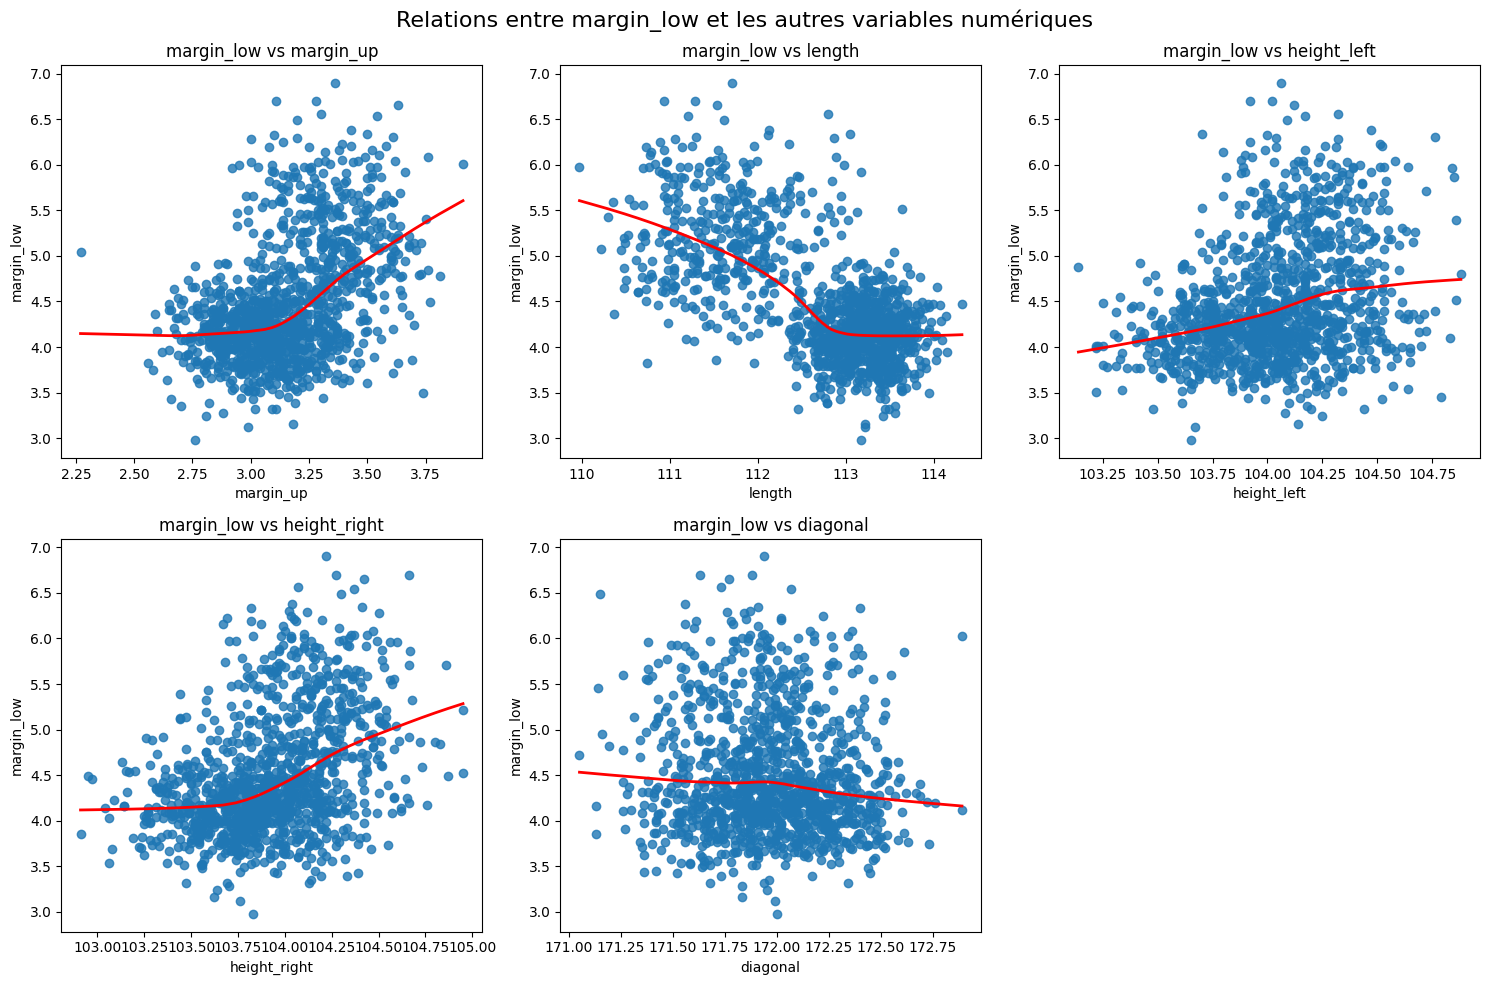

Image enregistrée dans le dossier etude_output.


In [203]:
# Visualisation des relations entre margin_low et les autres variables numériques
# pour voir si margin_low est corrélé à d'autres variables
# On utilise des graphiques de régression pour visualiser les tendances

fig, axes = plt.subplots(2, 3, figsize=(15, 10)) # Création d'une grille de sous-graphiques
axes = axes.flatten() # Aplatit la grille pour faciliter l'accès aux sous-graphiques

var_list_linearite = ["margin_up", "length", "height_left", "height_right", "diagonal"]


# Boucle pour créer les graphiques de régression pour chaque variable numérique sans margin_low
for i, var in enumerate(var_list_linearite):
    sns.regplot(data=Xy_train_rli, x=var, y="margin_low", lowess = True, ax=axes[i], line_kws={"color": "red", "linewidth": 2})
    axes[i].set_title(f"margin_low vs {var}")

axes[-1].set_visible(False)  # Cache la 6ème case vide

plt.suptitle("Relations entre margin_low et les autres variables numériques", fontsize=16)
plt.tight_layout()
plt.savefig(f"{OUTPUT_FOLDER}/RLI_stats_relations_margin_low.png")
plt.show()

print(f"Image enregistrée dans le dossier {OUTPUT_FOLDER}.")

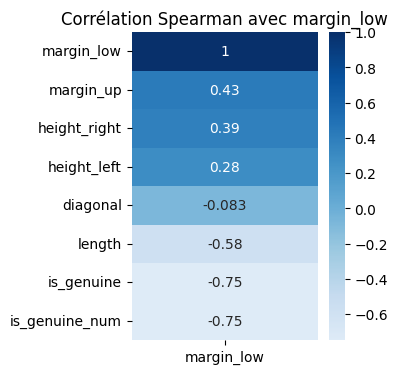

Image enregistrée dans le dossier etude_output.


In [204]:
# Matrice de corrélation de spearman
correlation_spearman_rli = Xy_train_rli.corr(method='spearman')["margin_low"].sort_values(ascending=False)

corr = correlation_spearman_rli.to_frame()

plt.figure(figsize=(3, 4))
sns.heatmap(corr, annot=True, cmap="Blues", center=0)
plt.title("Corrélation Spearman avec margin_low")
plt.savefig(f"{OUTPUT_FOLDER}/RLI_stats_correlation_spearman.png")
plt.show()

print(f"Image enregistrée dans le dossier {OUTPUT_FOLDER}.")

##### Indépendance des résidus → OK 

**Interprétation de la statistique Durbin-Watson**

La statistique varie entre 0 et 4  
* Si ≈ 2 → pas d'autocorrélation, résidus indépendants (c'est ce qu'on veut)  
* Si < 2 (proche de 0) → autocorrélation positive (un résidu élevé tend à être suivi d'un autre résidu élevé)  
* Si > 2 (proche de 4) → autocorrélation négative

In [205]:
########### AVEC MODELE 1 (sans isgenuine_num) ###########
# Le Durbin-Watson est une statistique qui teste l'autocorrélation des résidus d'un modèle de régression.
# Pour rappel, présent dans le summary OLS

dw_stat = durbin_watson(model_diag_1.resid)
print(f"Durbin-Watson : {dw_stat:.3f}")

Durbin-Watson : 1.981


In [206]:
########### AVEC MODELE 2 (en tenant compte de isgenuine_num) ###########

# Le Durbin-Watson est une statistique qui teste l'autocorrélation des résidus d'un modèle de régression.
# Pour rappel, présent dans le summary OLS

dw_stat = durbin_watson(model_diag_2.resid)
print(f"Durbin-Watson : {dw_stat:.3f}")

Durbin-Watson : 2.023


##### Homoscédasticité → Partiellement OK

Hypothèse : la variance des erreurs doit être constante.  
--> Les erreurs doivent être dispersées partout, peu importe la valeur prédite.  
--> On va visualiser comment l'erreur varie en fonction du niveau de prédiction.

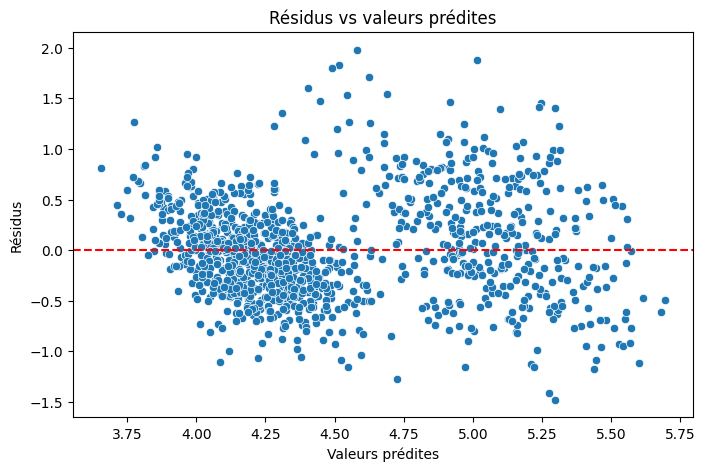

Image enregistrée dans le dossier etude_output.


In [207]:
############# TEST AVEC MODEL 1 (sans isgenuine_num) #############

residus_1 = model_diag_1.resid # valeurs des résidus du modèle (erreurs)
fitted_1 = model_diag_1.fittedvalues # valeurs prédites par le modèle

plt.figure(figsize=(8,5))
sns.scatterplot(x=fitted_1, y=residus_1)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Valeurs prédites")
plt.ylabel("Résidus")
plt.title("Résidus vs valeurs prédites")
plt.savefig(f"{OUTPUT_FOLDER}/RLI_stats_residus_vs_predites.png")
plt.show()

print(f"Image enregistrée dans le dossier {OUTPUT_FOLDER}.")

Observations  
--> Les points sont centrés autour de 0  
--> On observe deux groupes, un groupe à gauche peu dispersé, un groupe à droite beaucoup plus dispersé.  

Interprétation  
--> Variance des erreurs dépend du niveau des prédictions  
--> Modèle plus fiable sur certaines régions que d'autres  

Conclusion  
--> Homoscédasticité partielle

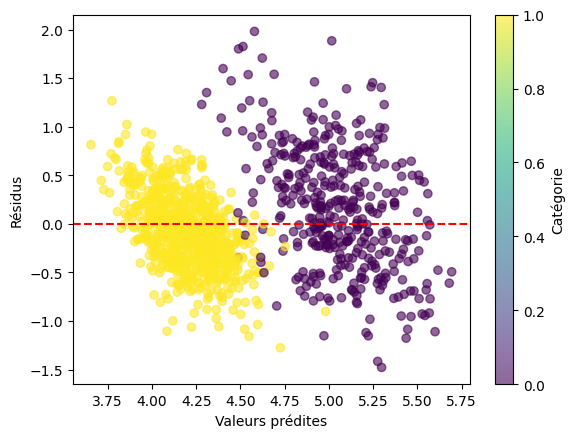

Image enregistrée dans le dossier etude_output.


In [208]:
# Graphique des résidus vs valeurs prédites avec les couleurs selon la variable "is_genuine"
plt.scatter(model_diag_1.fittedvalues, model_diag_1.resid,
            c=Xy_train_rli["is_genuine"], cmap='viridis', alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Valeurs prédites")
plt.ylabel("Résidus")
plt.colorbar(label='Catégorie')
plt.savefig(f"{OUTPUT_FOLDER}/RLI_stats_residus_vs_predites_1.png")
plt.show()

print(f"Image enregistrée dans le dossier {OUTPUT_FOLDER}.")

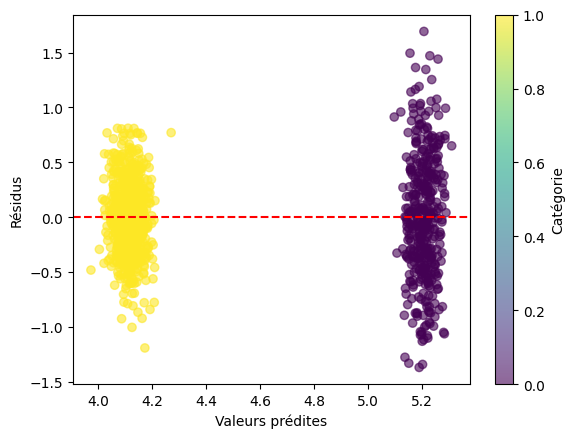

Image enregistrée dans le dossier etude_output.


In [209]:
############# TEST AVEC MODEL 2 (en tenant compte de isgenuine_num) #############
# Colorer le graphique selon une variable catégorielle candidate
plt.scatter(model_diag_2.fittedvalues, model_diag_2.resid,
            c=Xy_train_rli["is_genuine"], cmap='viridis', alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Valeurs prédites")
plt.ylabel("Résidus")
plt.colorbar(label='Catégorie')
plt.savefig(f"{OUTPUT_FOLDER}/RLI_stats_residus_vs_predites_2.png")
plt.show()

print(f"Image enregistrée dans le dossier {OUTPUT_FOLDER}.")

##### Normalité de la distribution des résidus → NOK

**Rappel des conditions du test de Shapiro-Wilk**  

-- Hypothèses  
* H0 : l'échantillon (ici, les résidus) provient d'une population suivant une loi normale.
* H1 : l'échantillon ne provient pas d'une population normale.
* Si p-value > α (généralement 0.05) → on ne rejette pas H0 → on considère la normalité comme acceptable.
* Si p-value ≤ α → on rejette H0 → la distribution s'écarte significativement de la normalité.

-- Taille de l'échantillon : petits à moyen échantillons (<~2000)  
-- Indépendance des observations  
-- Variables continues  
-- Nettoyage des NaN  
-- Compréhension des outliers car susceptibles d'influencer fortement le test.

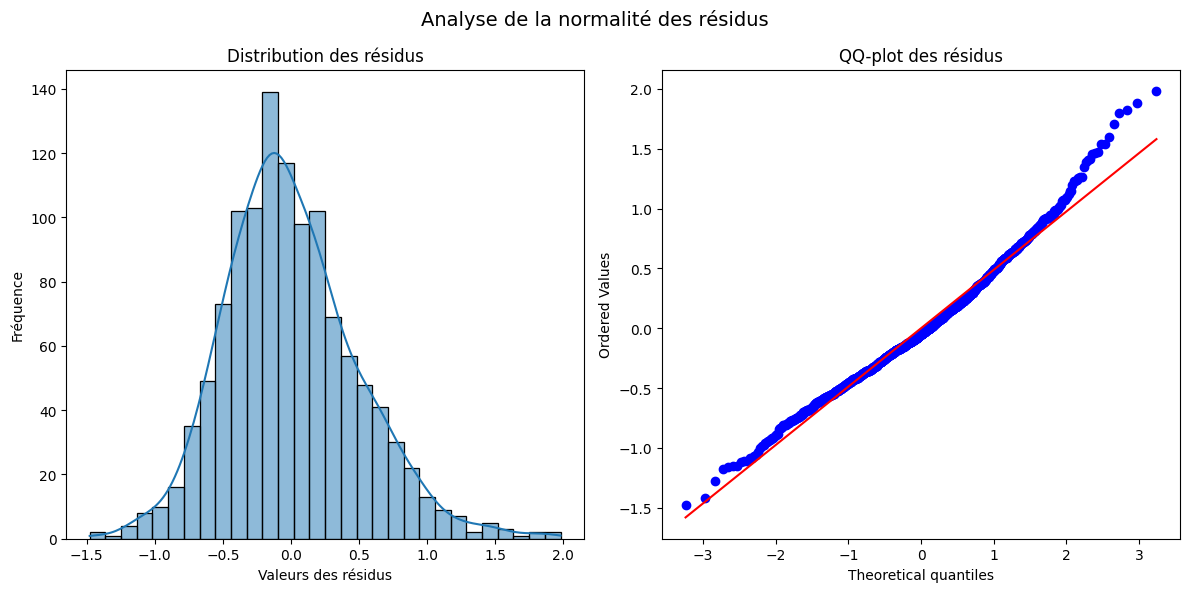

Test de Shapiro-Wilk : statistique=0.9839, p-value=0.0000
------------------------------------------------------------
Image enregistrée dans le dossier etude_output.


In [210]:
############ AVEC MODEL 1 (sans isgenuine_num) ############

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Histogramme des résidus
sns.histplot(data=residus_1 , kde=True, bins=30, ax=axes[0])
axes[0].set_title("Distribution des résidus")
axes[0].set_xlabel("Valeurs des résidus")
axes[0].set_ylabel("Fréquence")

# QQ-plot des résidus
stats.probplot(residus_1, dist="norm", plot=axes[1])
axes[1].set_title("QQ-plot des résidus")

plt.suptitle("Analyse de la normalité des résidus", fontsize=14)
plt.tight_layout()
plt.savefig(f"{OUTPUT_FOLDER}/RLI_stats_histogrammes_residus_1.png")
plt.show()

# Test de Shapiro-Wilk
stat, p_value = stats.shapiro(residus_1)
print(f"Test de Shapiro-Wilk : statistique={stat:.4f}, p-value={p_value:.4f}")
print(f"{'-'*60}")
print(f"Image enregistrée dans le dossier {OUTPUT_FOLDER}.")

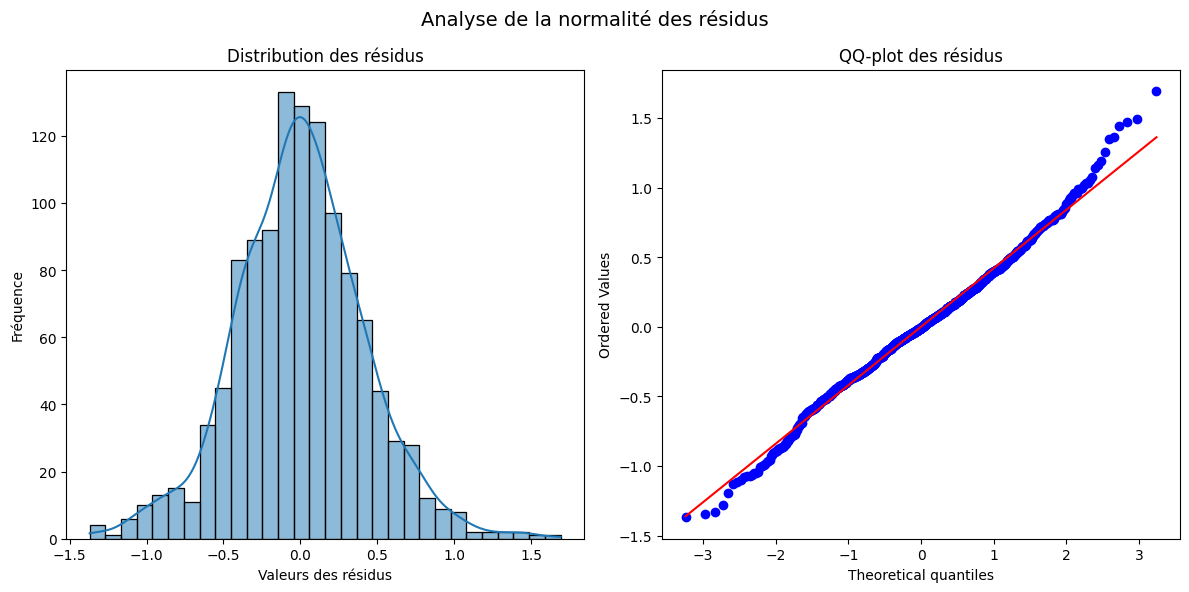

Test de Shapiro-Wilk : statistique=0.9932, p-value=0.0000
------------------------------------------------------------
Image enregistrée dans le dossier etude_output.


In [211]:
############# AVEC MODEL 2 (en tenant compte de isgenuine_num) ############

residus_2 = model_diag_2.resid # valeurs des résidus du modèle (erreurs)
fitted_2 = model_diag_2.fittedvalues # valeurs prédites par le modèle

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Histogramme des résidus
sns.histplot(data=residus_2, kde=True, bins=30, ax=axes[0])
axes[0].set_title("Distribution des résidus")
axes[0].set_xlabel("Valeurs des résidus")
axes[0].set_ylabel("Fréquence")

# QQ-plot des résidus
stats.probplot(residus_2, dist="norm", plot=axes[1])
axes[1].set_title("QQ-plot des résidus")

plt.suptitle("Analyse de la normalité des résidus", fontsize=14)
plt.tight_layout()
plt.savefig(f"{OUTPUT_FOLDER}/RLI_stats_histogrammes_residus_2.png")
plt.show()

# Test de Shapiro-Wilk
stat, p_value = stats.shapiro(residus_2)
print(f"Test de Shapiro-Wilk : statistique={stat:.4f}, p-value={p_value:.4f}")
print(f"{'-'*60}")
print(f"Image enregistrée dans le dossier {OUTPUT_FOLDER}.")

--- CONCLUSION ---  

* Cette hypothèse n'est pas respectée, probablement pour la même raison que l'hétéroscédasticité : le mélange de deux populations aux comportements différents (vrais et faux billets) au sein des résidus globaux.

* Comme pour l'homoscédasticité, cette violation n'invalide pas les prédictions du modèle. L'objectif ici étant l'imputation de valeurs manquantes (estimation ponctuelle), le modèle OLS est conservé malgré cette limite.

##### Absence de multicolinéarité → OK

* **Hypothèse** → H0 : absence de relation linéaire entre une variable explicative et les autres  
* **Méthode** → On va calculer le VIF (Variance Inflation Factor). Interprétation :
    * VIF = 1 --> aucune redondance  
    * VIF < 5 --> acceptable  
    * VIF > 10 --> problème

In [212]:
# Calcul du VIF (Variance Inflation Factor) pour détecter la multicolinéarité entre les variables explicatives
# Basé sur modèle 2 (avec is_genuine_num)

X_vif = add_constant(X_train_rli) #ajout d'une constante pour le calcul du VIF, exigence de la fonction variance_inflation_factor
vif = pd.DataFrame()
vif["variable"] = X_vif.columns
vif["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
vif = vif[vif["variable"] != "const"].sort_values("VIF", ascending=False)
print(vif)

         variable       VIF
6  is_genuine_num  4.617996
2          length  3.482500
1       margin_up  1.646540
4    height_right  1.318524
3     height_left  1.176047
5        diagonal  1.021794


**--- Conclusion ---**  

VIF < 5 pour toutes les variables → acceptable  
"diagonal" VIF est excellent.  
=> Absence de multicolinéarité.  
CONDITION OK.

<div style="border: 1px solid orange;" >
<h3 style="margin: auto; padding: 20px">3.4 Apprentissage du modèle </h3>
</div>

##### Pour rappel, données utilisées dans cette partie

`X_train_rli, y_train_rli`  
`X_test_rli, y_test_rli`  

##### Scaling

**Remarque :**

Le scaling n'est pas nécessaire pour un modèle de régression linéaire (les prédictions et performances restent identiques avec ou sans), mais il est tout de même appliqué ici par bonne pratique.  
Ainsi, si l'on souhaite par exemple tester un autre modèle pour l'imputation des valeurs manquantes nécessitant des données scalées (KNN, etc.), les données seront déjà prêtes à l'emploi.

In [213]:
# Instanciation du scaler pour la normalisation des données
scaler = StandardScaler()

# On fit et transforme les données d'entraînement, puis on transforme les données de test avec le même scaler
X_train_rli_scaled = scaler.fit_transform(X_train_rli)
X_test_rli_scaled = scaler.transform(X_test_rli)

print("Données normalisées :")
print(X_train_rli_scaled[:5])  # Affiche les 5 premières lignes des données normalisées

# Vérification de la normalisation en affichant les moyennes et écarts-types des colonnes normalisées
print("\nMoyennes des colonnes normalisées :")
print(X_train_rli_scaled.mean(axis=0))
print("\nÉcarts-types des colonnes normalisées :")
print(X_train_rli_scaled.std(axis=0))
print("\nMoyenne et écart-type de X_train_rli_scaled :\n", X_train_rli_scaled.mean(), X_train_rli_scaled.std())

Données normalisées :
[[ 1.05  0.77 -1.72 -0.43  0.79  0.72]
 [ 1.05 -0.69 -0.45  0.18 -1.55 -1.4 ]
 [-2.06  1.09 -1.08 -0.86  1.03  0.72]
 [-0.32 -1.11  1.31  0.76  1.83 -1.4 ]
 [ 1.94 -0.61  1.61  0.94 -0.75 -1.4 ]]

Moyennes des colonnes normalisées :
[ 0. -0.  0.  0. -0. -0.]

Écarts-types des colonnes normalisées :
[1. 1. 1. 1. 1. 1.]

Moyenne et écart-type de X_train_rli_scaled :
 -1.5815142800928156e-15 1.0


##### Modèle de régression linéaire : Instanciation et Fit

In [214]:
model_rli = LinearRegression().fit(X_train_rli_scaled, y_train_rli)

##### Prédictions

In [215]:
y_pred_rli = model_rli.predict(X_test_rli_scaled)

##### Métriques

In [216]:
print("RMSE :", root_mean_squared_error(y_test_rli, y_pred_rli))
print("R² :", r2_score(y_test_rli, y_pred_rli))
print("MAE :", mean_absolute_error(y_test_rli, y_pred_rli))

RMSE : 0.3706676796239568
R² : 0.6740384594304603
MAE : 0.2894912216607687


##### Comparaison des prédictions avec les données réelles

In [217]:
# Comparaison des prédictions avec les valeurs réelles
df_comparaison_rli = pd.DataFrame({
    "Valeurs réelles": y_test_rli,
    "Prédictions": y_pred_rli
})
df_comparaison_rli.reset_index(drop=False, inplace=True)
display(df_comparaison_rli.head())

,index,Valeurs réelles,Prédictions
0,1208,5.19,5.211443
1,178,4.26,4.100476
2,281,4.18,4.117453
3,561,3.93,4.127238
4,891,4.25,4.042756


In [218]:
# Dépivoter df_comparaison_rli pour avoir une colonne indiquant Valeurs réelles ou Prédictions, et une autre colonne indiquant la valeur correspondante
depivot_rli = df_comparaison_rli.melt(id_vars=["index"], value_vars=["Valeurs réelles", "Prédictions"], var_name="Type", value_name="Valeur")
depivot_rli

,index,Type,Valeur
0,1208,Valeurs réelles,5.190000
1,178,Valeurs réelles,4.260000
2,281,Valeurs réelles,4.180000
3,561,Valeurs réelles,3.930000
4,891,Valeurs réelles,4.250000
...,...,...,...
581,1491,Prédictions,5.179817
582,493,Prédictions,4.063303
583,494,Prédictions,4.131934
584,1080,Prédictions,5.186464


C:\Users\tphnr\AppData\Local\Temp\ipykernel_12652\2605035393.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=depivot_rli, y="Valeur", x="Type", ax=ax, palette={"Valeurs réelles": "lightblue", "Prédictions": "lightgreen"})


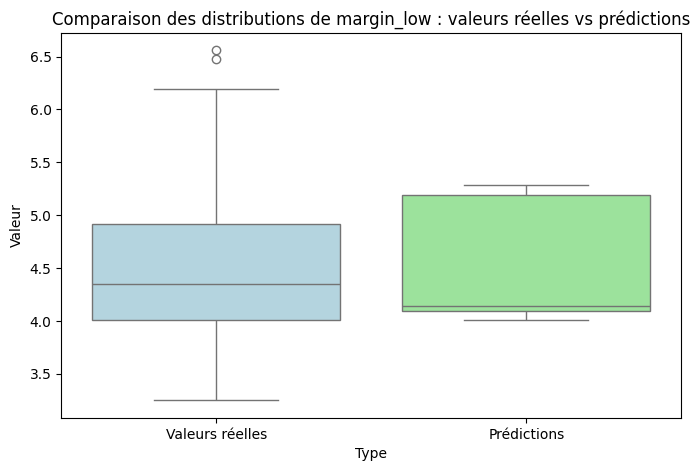

Image enregistrée dans le dossier etude_output.


In [219]:
# Boxplot pour comparer les distributions des valeurs réelles et des prédictions
fig, ax = plt.subplots(figsize=(8,5))
sns.boxplot(data=depivot_rli, y="Valeur", x="Type", ax=ax, palette={"Valeurs réelles": "lightblue", "Prédictions": "lightgreen"})
plt.title("Comparaison des distributions de margin_low : valeurs réelles vs prédictions")
plt.savefig(f"{OUTPUT_FOLDER}/RLI_apprentissage_comparaison_distributions_margin_low.png")
plt.show()

print(f"Image enregistrée dans le dossier {OUTPUT_FOLDER}.")

<div style="border: 1px solid orange;" >
<h3 style="margin: auto; padding: 20px">3.5 Utilisation du modèle sur les valeurs manquantes </h3>
</div>

##### Pour rappel, données utilisées dans cette partie

`X_rli, y_rli`  
`X_missing`  

##### Scaling

In [220]:
# On refit le scaler sur l'ensemble des données sans na pour la prédiction finale
X_rli_scaled = scaler.fit_transform(X_rli)

# On applique le même scaler sur l'ensemble des données avec valeurs manquantes
X_missing_scaled = scaler.transform(X_missing)

##### Entraînement sur tout le df sans na

In [221]:
# On refit le modèle sur l'ensemble des données complètes sans na pour la prédiction finale
model_rli.fit(X_rli_scaled, y_rli)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


##### Prédictions

In [222]:
y_pred_missing = model_rli.predict(X_missing_scaled)

##### Imputation des valeurs manquantes

In [223]:
df_missing["margin_low"] = y_pred_missing

##### Reconstruction finale

In [224]:
df_final = pd.concat([df_sans_na, df_missing])
df_final = df_final.sort_index()

display(df_final.head())

,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length,is_genuine_num
0,True,171.81,104.86,104.95,4.52,2.89,112.83,1
1,True,171.46,103.36,103.66,3.77,2.99,113.09,1
2,True,172.69,104.48,103.50,4.40,2.94,113.16,1
3,True,171.36,103.91,103.94,3.62,3.01,113.51,1
4,True,171.73,104.28,103.46,4.04,3.48,112.54,1


##### Vérification valeurs manquantes

In [225]:
print(f"Valeurs manquantes restantes : {df_final['margin_low'].isna().sum()}")
print(f"{'='*30}")
print(df_final.info())

Valeurs manquantes restantes : 0
<class 'pandas.DataFrame'>
Index: 1500 entries, 0 to 1499
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   is_genuine      1500 non-null   bool   
 1   diagonal        1500 non-null   float64
 2   height_left     1500 non-null   float64
 3   height_right    1500 non-null   float64
 4   margin_low      1500 non-null   float64
 5   margin_up       1500 non-null   float64
 6   length          1500 non-null   float64
 7   is_genuine_num  1500 non-null   int64  
dtypes: bool(1), float64(6), int64(1)
memory usage: 95.2 KB
None


##### Vérification de la cohérence des valeurs imputées

In [226]:
print("Statistiques margin_low - valeurs observées :")
print(df_sans_na["margin_low"].describe())

print("\nStatistiques margin_low - valeurs imputées :")
print(df_missing["margin_low"].describe())

Statistiques margin_low - valeurs observées :
count    1463.000000
mean        4.485967
std         0.663813
min         2.980000
25%         4.015000
50%         4.310000
75%         4.870000
max         6.900000
Name: margin_low, dtype: float64

Statistiques margin_low - valeurs imputées :
count    37.000000
mean      4.359368
std       0.470245
min       3.993571
25%       4.096960
50%       4.125390
75%       4.198423
max       5.302069
Name: margin_low, dtype: float64


In [227]:
# Ajout d'une colonne "origine" pour indiquer si la valeur de "margin_low" est observée ou imputée
df_final["origine"] = np.where(df_final.index.isin(df_missing.index), "Imputée", "Observée")
df_final

,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length,is_genuine_num,origine
0,True,171.81,104.86,104.95,4.52,2.89,112.83,1,Observée
1,True,171.46,103.36,103.66,3.77,2.99,113.09,1,Observée
2,True,172.69,104.48,103.50,4.40,2.94,113.16,1,Observée
3,True,171.36,103.91,103.94,3.62,3.01,113.51,1,Observée
4,True,171.73,104.28,103.46,4.04,3.48,112.54,1,Observée
...,...,...,...,...,...,...,...,...,...
1495,False,171.75,104.38,104.17,4.42,3.09,111.28,0,Observée
1496,False,172.19,104.63,104.44,5.27,3.37,110.97,0,Observée
1497,False,171.80,104.01,104.12,5.51,3.36,111.95,0,Observée
1498,False,172.06,104.28,104.06,5.17,3.46,112.25,0,Observée


C:\Users\tphnr\AppData\Local\Temp\ipykernel_12652\2855820955.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_final, y="margin_low", x="origine", ax=ax, palette={"Observée": "yellow", "Imputée": "lightgreen"})


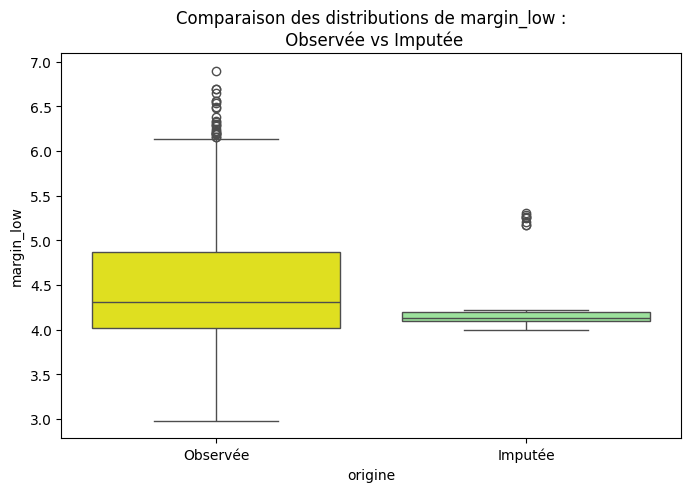

In [228]:
# Comparaison visuelle N°1 : valeurs observées vs valeurs imputées

fig, ax = plt.subplots(figsize=(8,5))
sns.boxplot(data=df_final, y="margin_low", x="origine", ax=ax, palette={"Observée": "yellow", "Imputée": "lightgreen"})
plt.title("Comparaison des distributions de margin_low :\n Observée vs Imputée")
plt.savefig(f"{OUTPUT_FOLDER}/RLI_imputation_comparaison_distributions_margin_low.png")
plt.show()

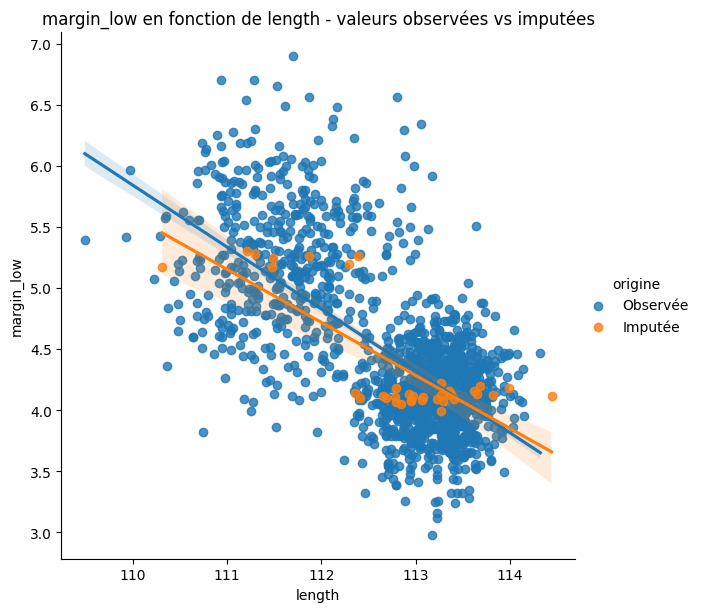

In [229]:
# Comparaison visuelle N°2 : valeurs observées vs valeurs imputées

sns.lmplot(x="length", y="margin_low", hue="origine", data=df_final, height=6)
plt.title("margin_low en fonction de length - valeurs observées vs imputées")
plt.savefig(f"{OUTPUT_FOLDER}/RLI_imputation_margin_low_vs_length.png")
plt.show()

In [230]:
df_final = df_final.reset_index(drop=False)


<div style="border: 1px solid white;background-color: rgb(47, 132, 171)" >
<h2 style="margin: auto; padding: 20px ; color : white">ETAPE 3 : ANALYSES UNIVARIEES ET MULTIVARIEES</h2>
</div>

<div style="border: 1px solid orange;" >
<h3 style="margin: auto; padding: 20px; ">3.1 Sélection des données</h3>
</div>

In [231]:
df_analyse = df_final.copy()
df_analyse

,index,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length,is_genuine_num,origine
0,0,True,171.81,104.86,104.95,4.52,2.89,112.83,1,Observée
1,1,True,171.46,103.36,103.66,3.77,2.99,113.09,1,Observée
2,2,True,172.69,104.48,103.50,4.40,2.94,113.16,1,Observée
3,3,True,171.36,103.91,103.94,3.62,3.01,113.51,1,Observée
4,4,True,171.73,104.28,103.46,4.04,3.48,112.54,1,Observée
...,...,...,...,...,...,...,...,...,...,...
1495,1495,False,171.75,104.38,104.17,4.42,3.09,111.28,0,Observée
1496,1496,False,172.19,104.63,104.44,5.27,3.37,110.97,0,Observée
1497,1497,False,171.80,104.01,104.12,5.51,3.36,111.95,0,Observée
1498,1498,False,172.06,104.28,104.06,5.17,3.46,112.25,0,Observée


In [232]:
variables_num = ["margin_low", "margin_up", "length", "height_left", "height_right", "diagonal"]

In [233]:
generate_stats(df_analyse, "df_analyse")

--- Infos générales sur les données du tableau : df_analyse ---
Dimensions du tableau (lignes, colonnes) : (1500, 10)


C:\Users\tphnr\AppData\Local\Temp\ipykernel_12652\540472084.py:41: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  dataSummary["dType_cat"] = pd.Categorical(dataSummary["dType"], categories=type_order, ordered=True)


,dType,naCount,count,unique,top,freq,freq%,mean,std,min,25%,50%,75%,max
index,int64,0,1500.0,NaN,NaN,NaN,NaN,749.5,433.157015,0.0,374.75,749.5,1124.25,1499.0
is_genuine_num,int64,0,1500.0,NaN,NaN,NaN,NaN,0.666667,0.471562,0.0,0.0,1.0,1.0,1.0
diagonal,float64,0,1500.0,NaN,NaN,NaN,NaN,171.95844,0.305195,171.04,171.75,171.96,172.17,173.01
height_left,float64,0,1500.0,NaN,NaN,NaN,NaN,104.029533,0.299462,103.14,103.82,104.04,104.23,104.88
height_right,float64,0,1500.0,NaN,NaN,NaN,NaN,103.920307,0.325627,102.82,103.71,103.92,104.15,104.95
margin_low,float64,0,1500.0,NaN,NaN,NaN,NaN,4.482844,0.659899,2.98,4.0275,4.31,4.87,6.9
margin_up,float64,0,1500.0,NaN,NaN,NaN,NaN,3.151473,0.231813,2.27,2.99,3.14,3.31,3.91
length,float64,0,1500.0,NaN,NaN,NaN,NaN,112.6785,0.87273,109.49,112.03,112.96,113.34,114.44
is_genuine,bool,0,1500,2,True,1000,66.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
origine,str,0,1500,2,Observée,1463,97.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Nombre de doublon(s) présent(s) : 0
-----


<div style="border: 1px solid orange;" >
<h3 style="margin: auto; padding: 20px; ">3.2 Répartition du type de billet</h3>
</div>

--- Répartition du type de billet ---
is_genuine
False     500
True     1000
Name: length, dtype: int64


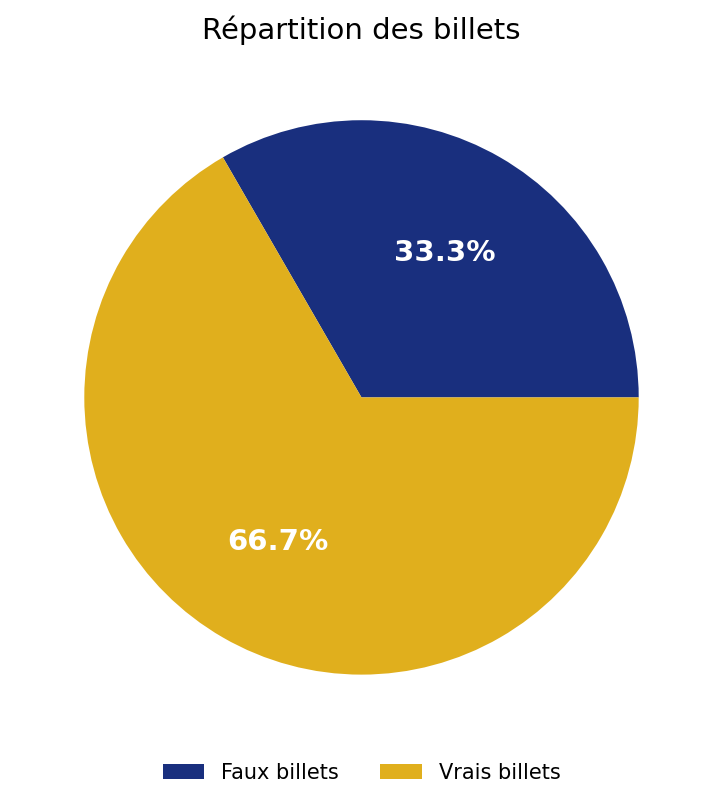

Image enregistrée dans le dossier etude_output.


In [234]:
# Répartition en quantité
counts = df_analyse.groupby("is_genuine")["length"].count()
print("--- Répartition du type de billet ---")
print(counts)

# Visualisation en proportions %
fig, ax = plt.subplots(figsize=(6, 6),dpi = 150)
wedges, texts, autotexts = ax.pie(
    counts,
    autopct="%1.1f%%",
    colors=["#192f7e", "#e0af1d"],
    textprops={"fontsize": 14, "color": "#ffffff", "fontweight": "bold"}
)
ax.set_title("Répartition des billets", fontsize=14)

# Légende centrée en bas
ax.legend(
    wedges,
    ["Faux billets", "Vrais billets"],
    loc="upper center",
    bbox_to_anchor=(0.5, 0),
    ncol=2,
    frameon=False
)

plt.savefig(f"{OUTPUT_FOLDER}/exploration_répartition_des_billets.png", bbox_inches="tight")
plt.show()

print(f"Image enregistrée dans le dossier {OUTPUT_FOLDER}.")

<div style="border: 1px solid orange;" >
<h3 style="margin: auto; padding: 20px; ">3.3 Détection et compréhension des outliers</h3>
</div>

In [235]:
df_analyse

,index,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length,is_genuine_num,origine
0,0,True,171.81,104.86,104.95,4.52,2.89,112.83,1,Observée
1,1,True,171.46,103.36,103.66,3.77,2.99,113.09,1,Observée
2,2,True,172.69,104.48,103.50,4.40,2.94,113.16,1,Observée
3,3,True,171.36,103.91,103.94,3.62,3.01,113.51,1,Observée
4,4,True,171.73,104.28,103.46,4.04,3.48,112.54,1,Observée
...,...,...,...,...,...,...,...,...,...,...
1495,1495,False,171.75,104.38,104.17,4.42,3.09,111.28,0,Observée
1496,1496,False,172.19,104.63,104.44,5.27,3.37,110.97,0,Observée
1497,1497,False,171.80,104.01,104.12,5.51,3.36,111.95,0,Observée
1498,1498,False,172.06,104.28,104.06,5.17,3.46,112.25,0,Observée


In [236]:
variables_num

['margin_low',
 'margin_up',
 'length',
 'height_left',
 'height_right',
 'diagonal']

--- OUTLIERS DÉTECTÉS (méthode IQR, seuils calculés par catégorie is_genuine) ---

margin_low (Vrai) : 9 outlier(s) | seuils [3.3 ; 5.0]
   10 3.16
   125 3.26
   390 3.26
   477 3.24
   571 3.25
   664 5.04
   788 3.12
   897 2.98
   901 3.28

margin_low (Faux) : 1 outlier(s) | seuils [3.7 ; 6.7]
   1290 6.90

margin_up (Vrai) : 5 outlier(s) | seuils [2.6 ; 3.6]
   48 3.61
   52 3.74
   197 3.62
   664 2.27
   980 3.56

margin_up (Faux) : 1 outlier(s) | seuils [2.8 ; 3.9]
   1029 3.91

length (Vrai) : 5 outlier(s) | seuils [112.2 ; 114.2]
   591 112.18
   728 111.76
   798 114.44
   951 112.17
   974 114.32

length (Faux) : 4 outlier(s) | seuils [110.0 ; 113.3]
   1082 109.49
   1122 113.85
   1325 113.64
   1453 109.93

height_left (Vrai) : 4 outlier(s) | seuils [103.1 ; 104.7]
   0 104.86
   491 104.83
   905 104.76
   965 104.79

height_left (Faux) : 7 outlier(s) | seuils [103.6 ; 104.8]
   1083 103.60
   1085 103.51
   1090 104.88
   1150 104.86
   1168 103.56
   1310 104.84
   13

,Vrai,Faux,Total
Variable,,,
margin_low,9,1,10
margin_up,5,1,6
length,5,4,9
height_left,4,7,11
height_right,9,1,10
diagonal,4,5,9


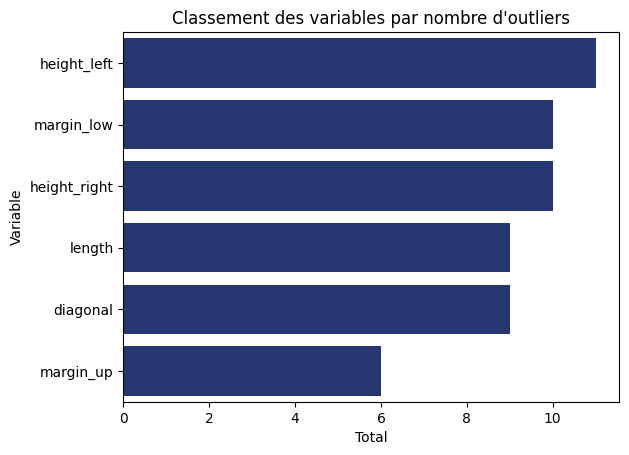

In [255]:
# La fonction reste identique, elle est déjà générique
def iqr_outliers(series):
    Q1, Q3 = series.quantile(.25), series.quantile(.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    mask = (series < lo) | (series > hi)
    return mask, lo, hi

print("--- OUTLIERS DÉTECTÉS (méthode IQR, seuils calculés par catégorie is_genuine) ---")
resultats = []

for col in variables_num:
    nb_par_categorie = {}

    for genuine_value, label in [(True, "Vrai"), (False, "Faux")]:
        sous_df = df_analyse[df_analyse["is_genuine"] == genuine_value]  # sous-ensemble par catégorie
        mask, lo, hi = iqr_outliers(sous_df[col])  # seuils propres à cette catégorie
        nb = int(mask.sum())
        nb_par_categorie[label] = nb

        if nb > 0:
            outlier_ids = sous_df.loc[mask, "index"].tolist()
            print(f"\n{col} ({label}) : {nb} outlier(s) | seuils [{lo:.1f} ; {hi:.1f}]")
            for i, v in zip(outlier_ids, sous_df.loc[mask, col]):
                print(f"   {i} {v:.2f}")

    resultats.append({"Variable": col, "Vrai": nb_par_categorie["Vrai"], "Faux": nb_par_categorie["Faux"]})

tableau_outliers = pd.DataFrame(resultats).set_index("Variable")
tableau_outliers["Total"] = tableau_outliers["Vrai"] + tableau_outliers["Faux"]

print("\n--- TABLEAU RÉCAPITULATIF DES OUTLIERS (seuils par catégorie) ---")
display(tableau_outliers)


sns.barplot(tableau_outliers.sort_values(by = "Total", ascending = False), x="Total", y="Variable", orient='h', color ="#192f7e")
plt.title("Classement des variables par nombre d'outliers")
plt.show()

<div style="border: 1px solid orange;" >
<h3 style="margin: auto; padding: 20px; ">3.4 Répartition en fonction de is_genuine</h3>
</div>

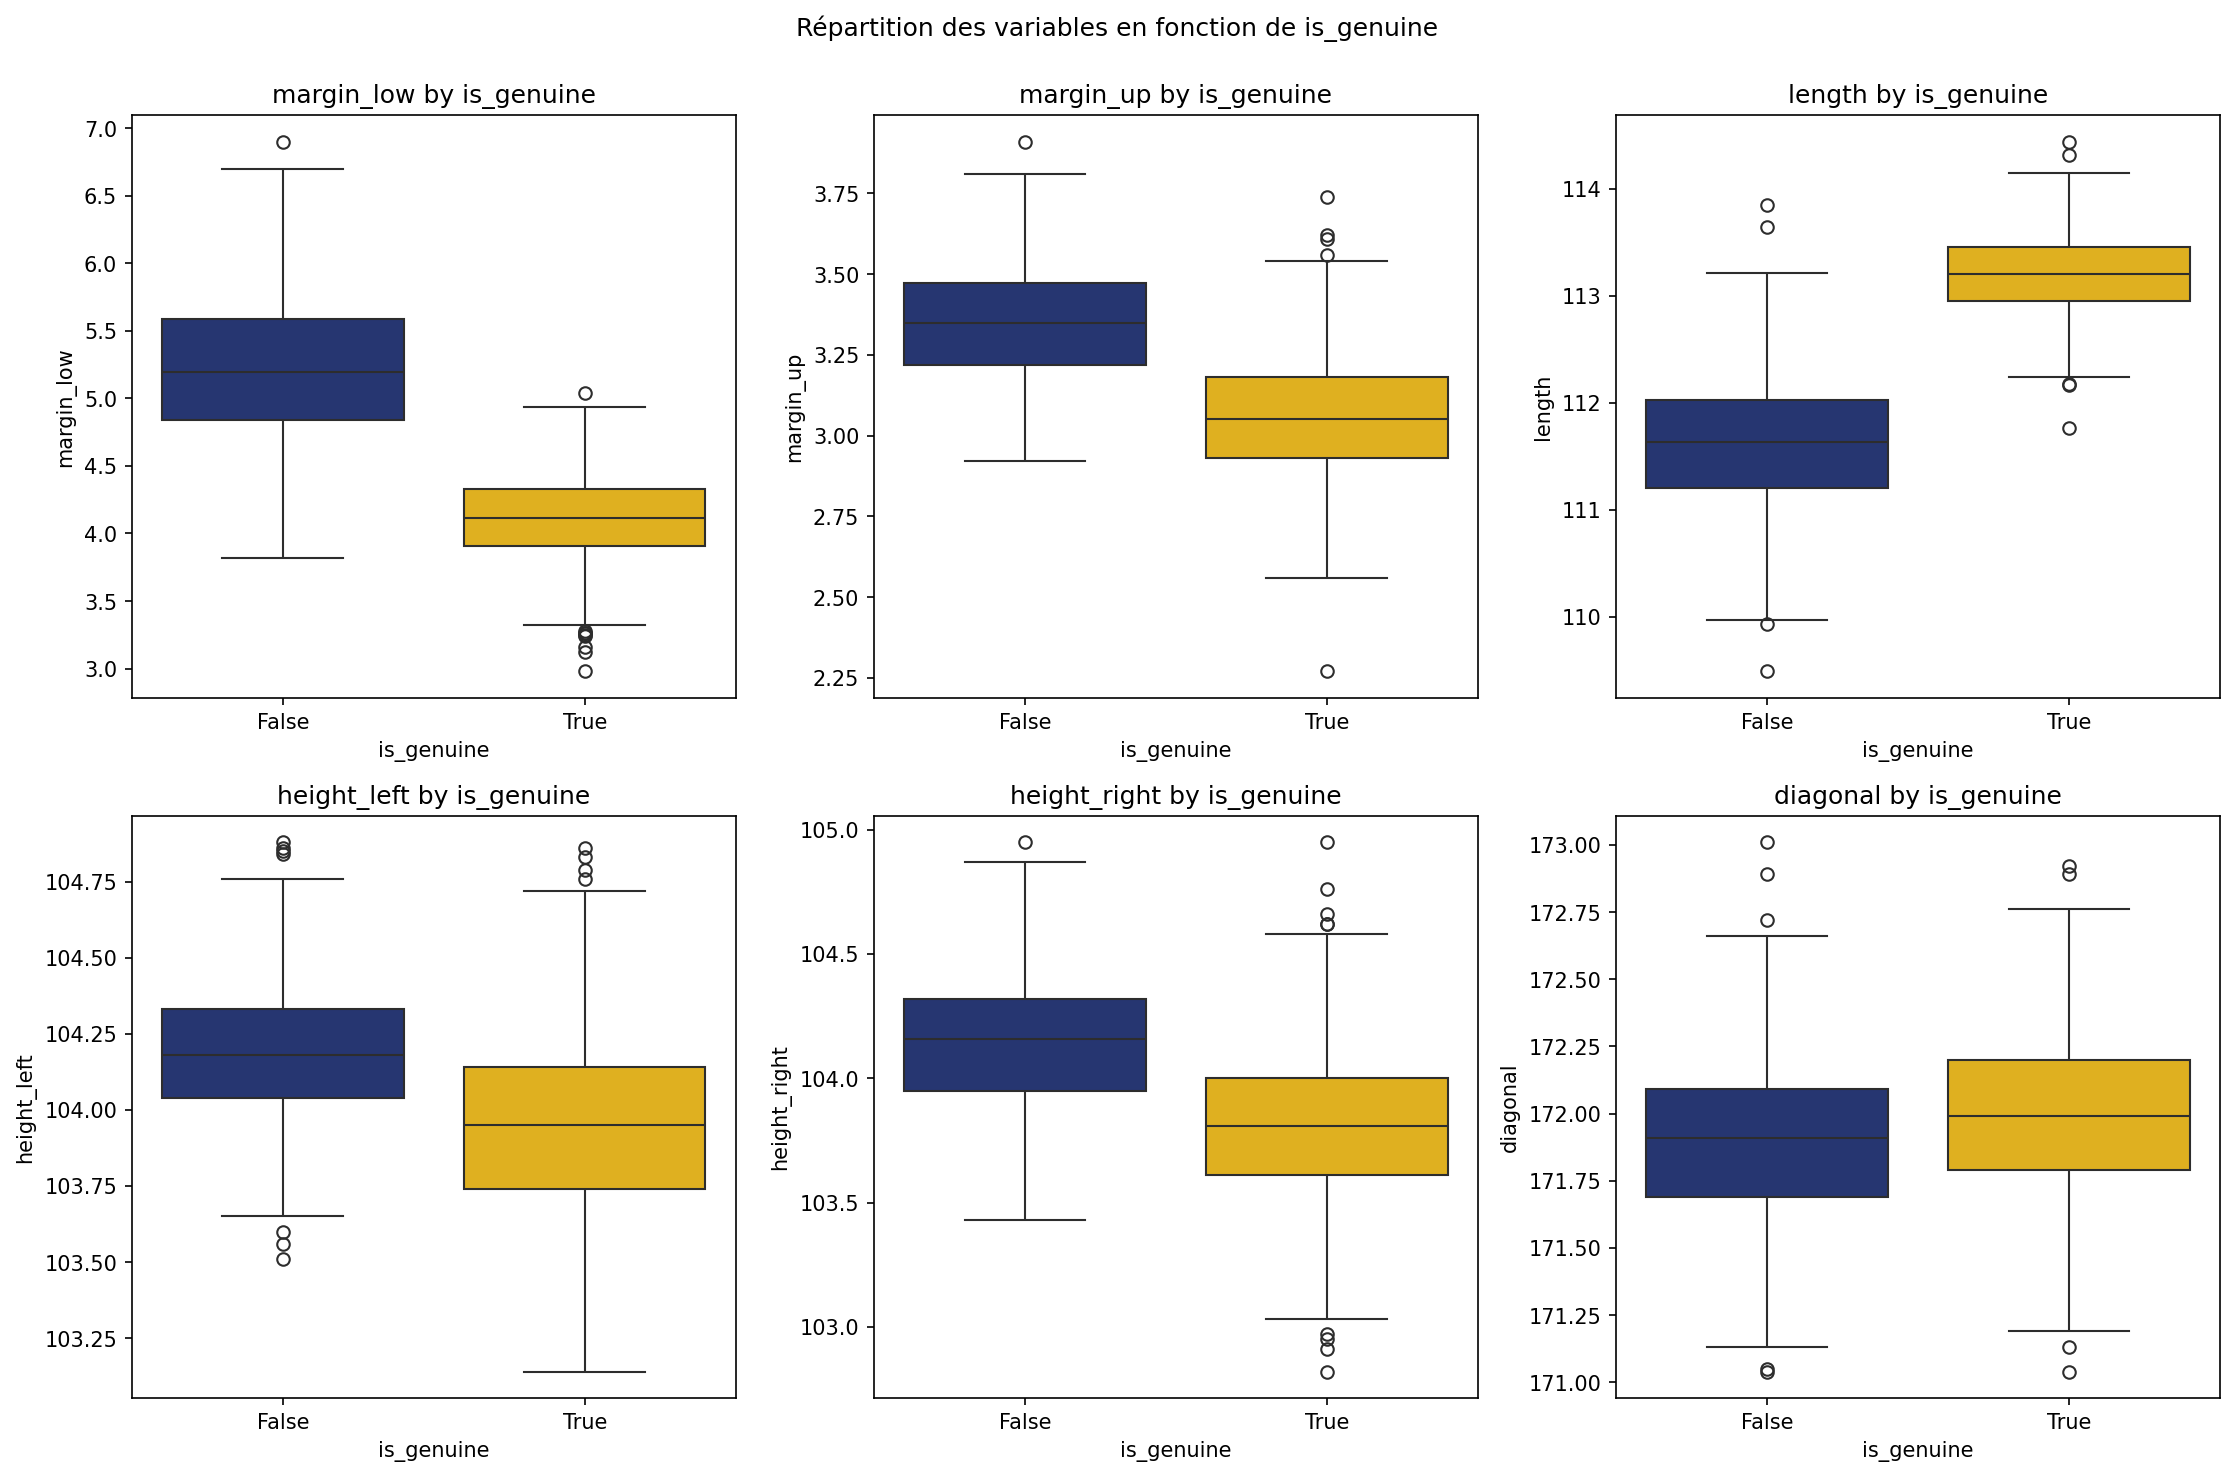

Image enregistrée dans le dossier etude_output.


In [238]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10), dpi = 150)
axes = axes.flatten()

palette = {False: "#192f7e", True: "#ffc000"}

for i, var in enumerate(variables_num):
    sns.boxplot(data=df_analyse, y=var, x="is_genuine", hue="is_genuine", palette=palette, legend=False, ax=axes[i])
    axes[i].set_title(f"{var} by is_genuine")

plt.suptitle("Répartition des variables en fonction de is_genuine\n")

plt.tight_layout()
plt.savefig(f"{OUTPUT_FOLDER}/exploration_variable_en_fonction_is-genuine.png")
plt.show()

print(f"Image enregistrée dans le dossier {OUTPUT_FOLDER}.")

<div style="border: 1px solid orange;" >
<h3 style="margin: auto; padding: 20px; ">3.5 Distribution + test de Shapiro-Wilk</h3>
</div>

**Rappel des conditions du test de Shapiro-Wilk**  

-- Hypothèses  
* H0 : l'échantillon provient d'une population suivant une loi normale.
* H1 : l'échantillon ne provient pas d'une population normale.
* Si p-value > α (généralement 0.05) → on ne rejette pas H0 → on considère la normalité comme acceptable.
* Si p-value ≤ α → on rejette H0 → la distribution s'écarte significativement de la normalité.

-- Taille de l'échantillon : petits à moyen échantillons (<~2000)  
-- Indépendance des observations  
-- Variables continues  
-- Nettoyage des NaN  
-- Compréhension des outliers car susceptibles d'influencer fortement le test.

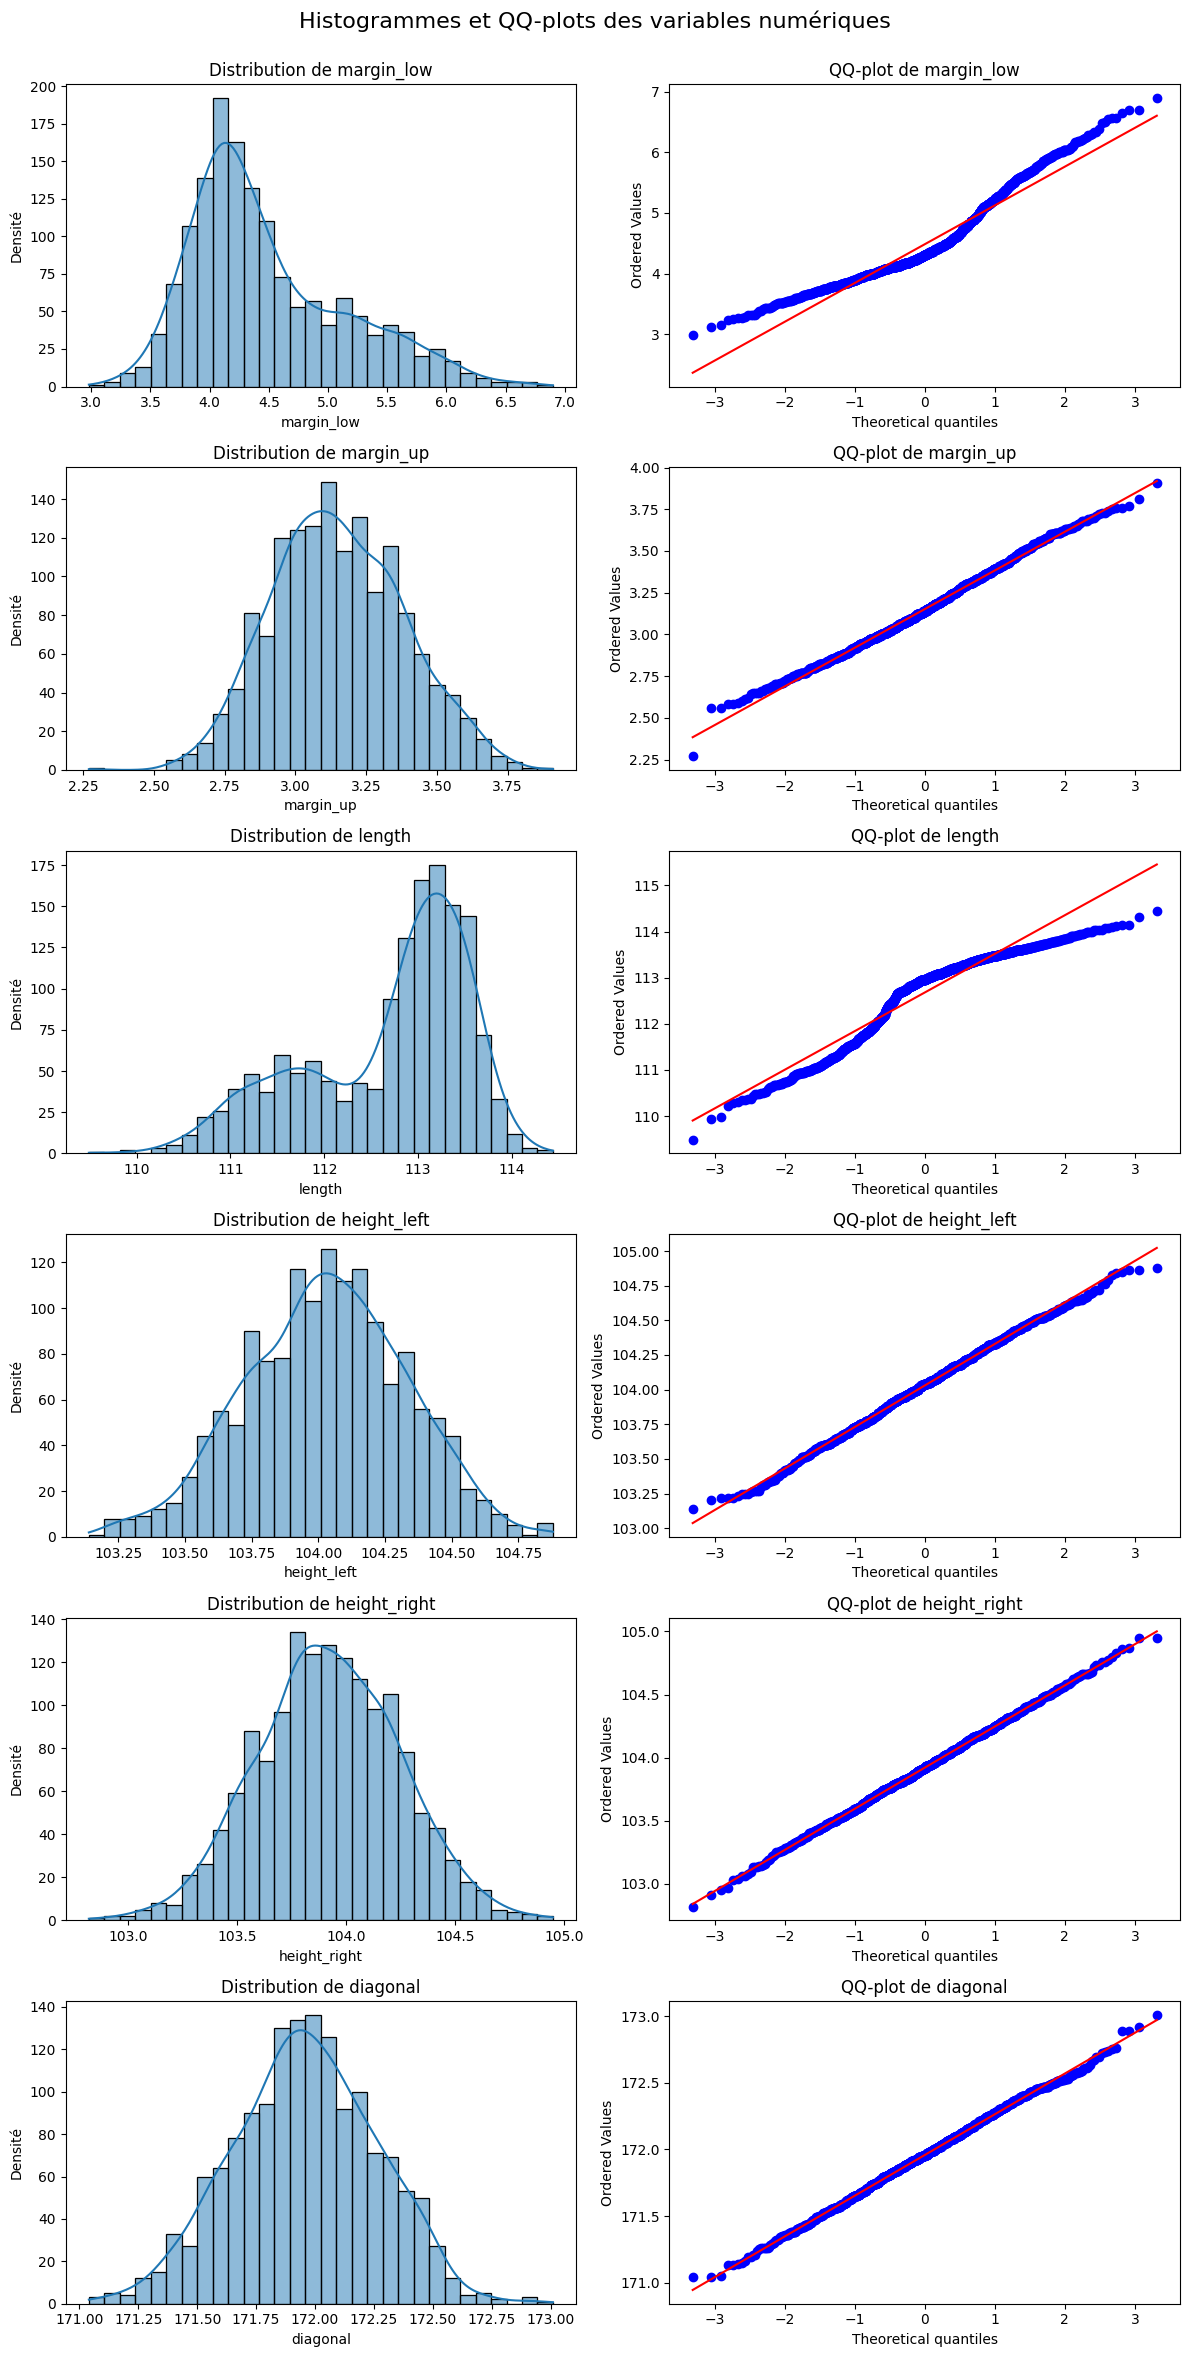

Image enregistrée dans le dossier etude_output.


In [239]:
# Génération des histogrammes + QQ-plots pour chaque variable numérique
n_vars = len(variables_num)

fig, axes = plt.subplots(n_vars, 2, figsize=(12, 4 * n_vars))

# Si une seule variable, axes n'est pas un tableau 2D -> on force la forme
if n_vars == 1:
    axes = axes.reshape(1, -1)

for i, var in enumerate(variables_num):

    # Distribution de la variable avec histogramme et courbe de densité
    sns.histplot(data=df_analyse, x=var, kde=True, bins=30, ax=axes[i, 0])
    axes[i, 0].set_title(f"Distribution de {var}")
    axes[i, 0].set_xlabel(var)
    axes[i, 0].set_ylabel("Densité")

    # QQ-plot
    stats.probplot(df_analyse[var], dist="norm", plot=axes[i, 1])
    axes[i, 1].set_title(f"QQ-plot de {var}")

plt.suptitle("Histogrammes et QQ-plots des variables numériques", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.98])  # réserve de l'espace en haut pour le suptitle
plt.savefig(f"{OUTPUT_FOLDER}/exploration_distribution_histo_QQ-plots.png")
plt.show()

print(f"Image enregistrée dans le dossier {OUTPUT_FOLDER}.")

In [240]:
# Calcul de la normalité des variables numériques avec le test de Shapiro-Wilk
# et affichage des résultats sous forme de dataframe pour un affichage plus clair

resultats_normalite = []

for var in variables_num:
    stat, p_value = stats.shapiro(df_analyse[var])
    normalite = "Oui" if p_value > 0.05 else "Non"
    resultats_normalite.append({
        "Variable": var,
        "Statistique": round(stat, 4),
        "p-value": round(p_value, 4),
        "Normalité (α=0.05)": normalite
    })

df_normalite = pd.DataFrame(resultats_normalite)

def colorer_normalite(col):
    """ Permet de colier en vert les variables qui respectent la normalité (p-value > 0.05) """
    return ["background-color: darkgreen" if v == "Oui" else "" for v in col]

df_normalite_style = df_normalite.style.apply(colorer_normalite, subset=["Normalité (α=0.05)"], axis=0)

print("--- TEST DE NORMALITÉ (Shapiro-Wilk) ---")
display(df_normalite_style)

--- TEST DE NORMALITÉ (Shapiro-Wilk) ---


,Variable,Statistique,p-value,Normalité (α=0.05)
0,margin_low,0.935700,0.000000,Non
1,margin_up,0.996200,0.000800,Non
2,length,0.917600,0.000000,Non
3,height_left,0.997900,0.051400,Oui
4,height_right,0.999500,0.980000,Oui
5,diagonal,0.998700,0.324100,Oui


**Remarque**   
Pour margin_up, en regardant la distribution ainsi que le QQ-plot, on pourrait tout de même accepter la normalité à alpha = 0.05

<div style="border: 1px solid orange;" >
<h3 style="margin: auto; padding: 20px; ">3.6 Scatterplots et matrice de corrélation (Spearman)</h3>
</div>

**Choix de Spearman (test non-paramétrique)** :

Au moins deux variables s'écartent fortement de la normalité → Spearman entre toutes les variables pour plus de robustesse.

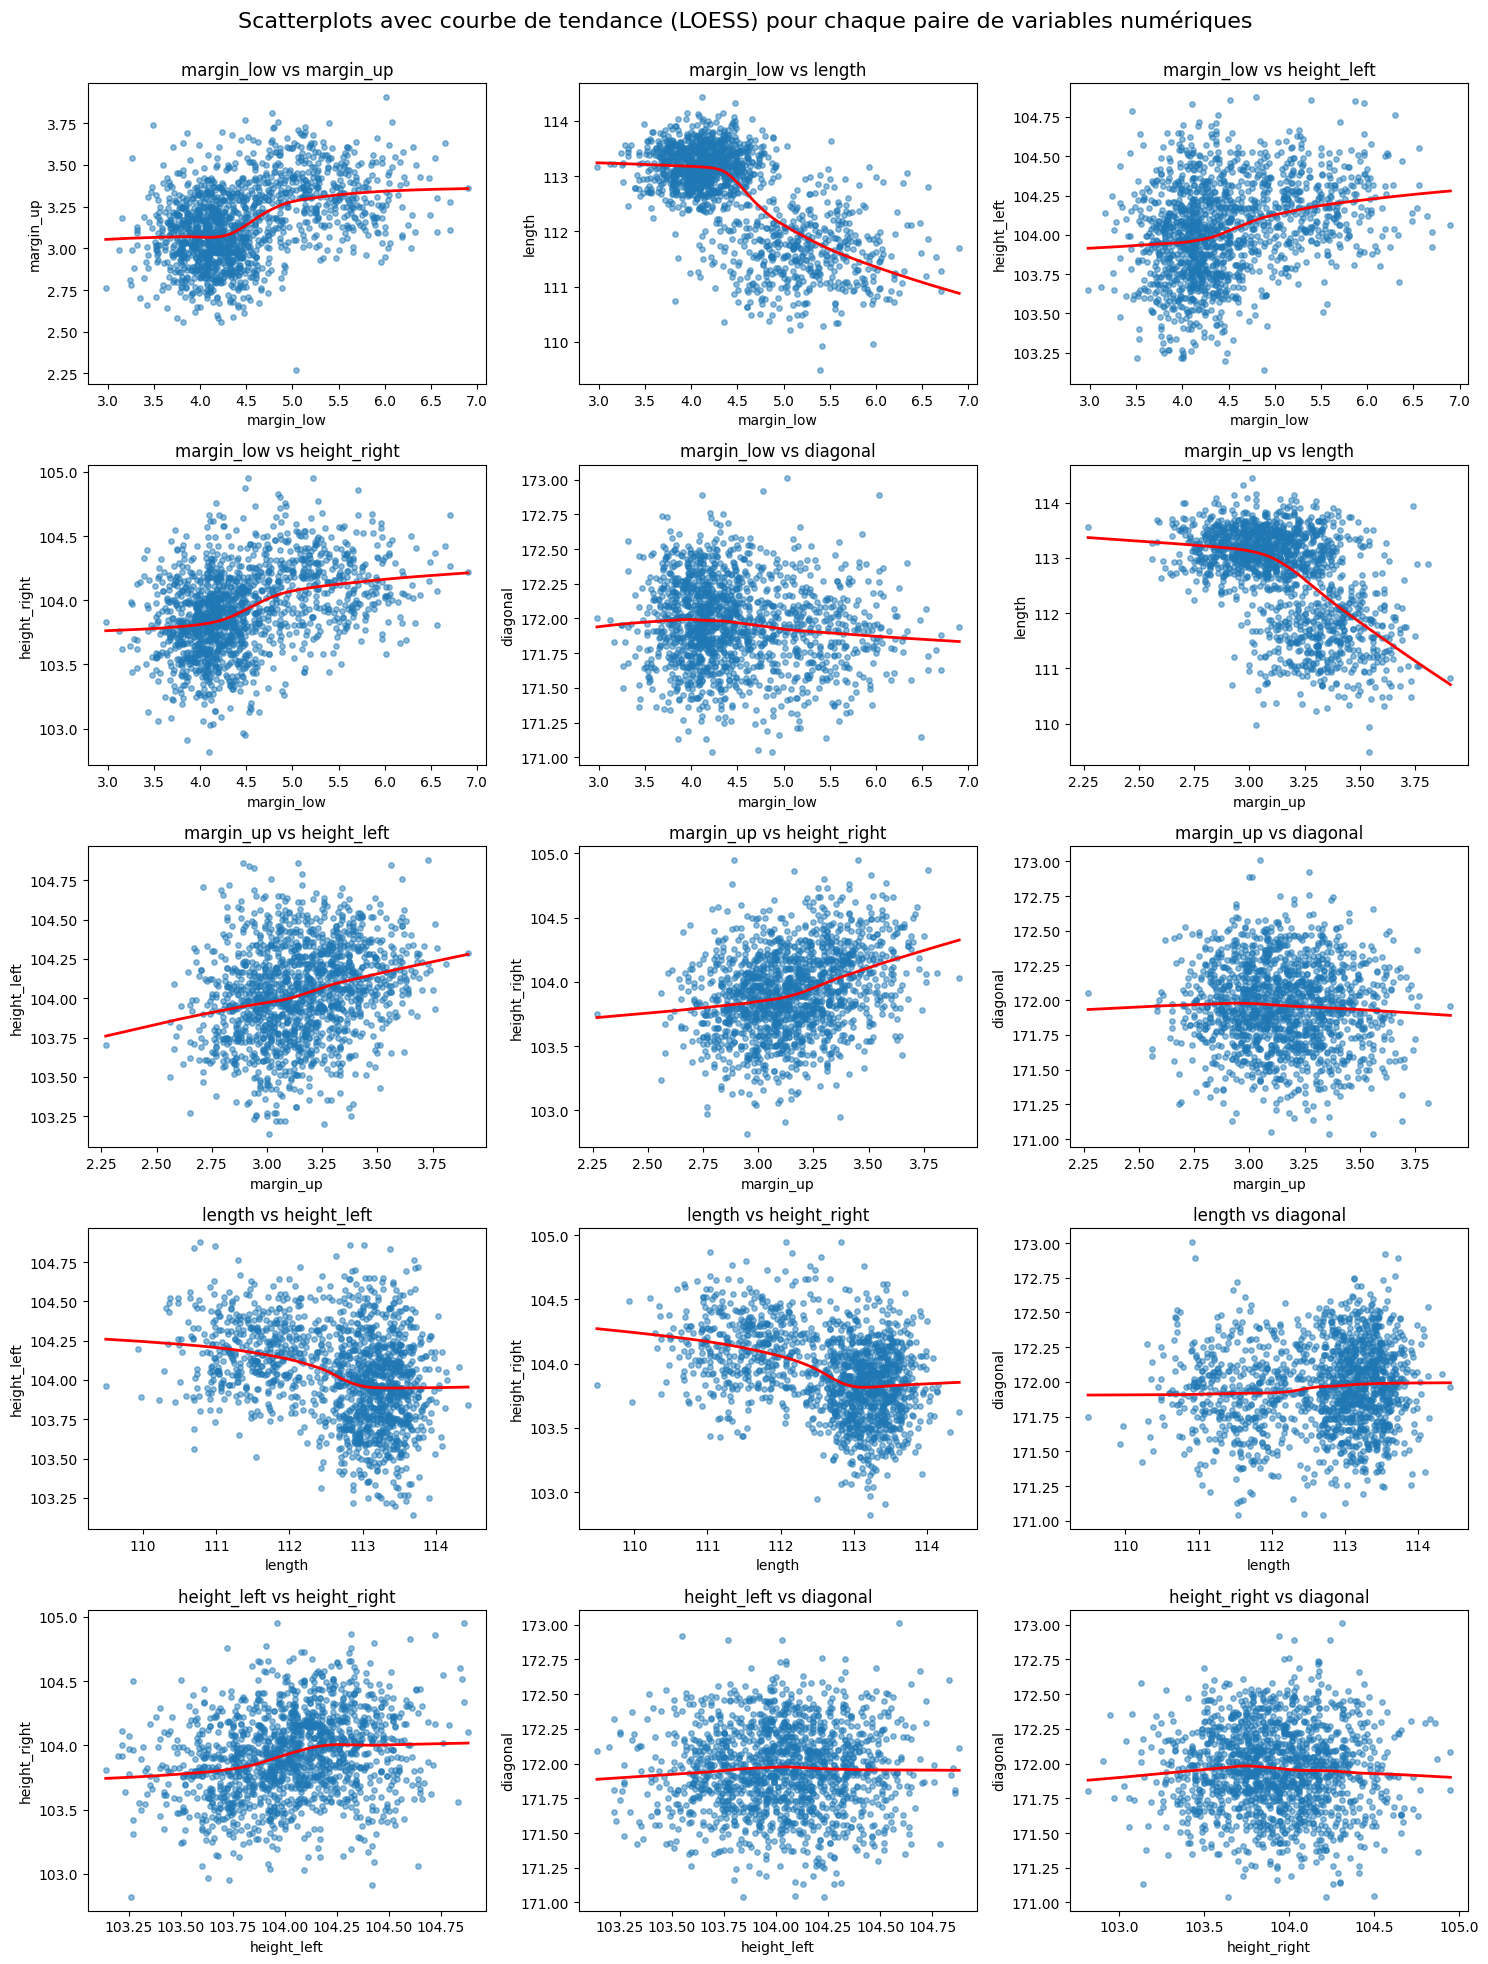

Image enregistrée dans le dossier etude_output.


In [241]:
# Génère un scatterplot + courbe de tendance (LOESS) pour chaque paire de variables numériques
paires = list(combinations(variables_num, 2))
n_paires = len(paires)

n_cols = 3
n_rows = -(-n_paires // n_cols)  # arrondi supérieur

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, (var1, var2) in enumerate(paires):
    sns.regplot(
        data=df_analyse, x=var1, y=var2, ax=axes[i],
        lowess=True,
        scatter_kws={"alpha": 0.5, "s": 15},
        line_kws={"color": "red", "linewidth": 2}
    )
    axes[i].set_title(f"{var1} vs {var2}")

# REMARQUE :
# lowess=True active une régression LOESS (Locally Weighted Scatterplot Smoothing), qui ajuste localement une courbe lissée au nuage de points, sans imposer de forme prédéfinie.

plt.suptitle("Scatterplots avec courbe de tendance (LOESS) pour chaque paire de variables numériques", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.98])  # réserve de l'espace en haut pour le suptitle
plt.savefig(f"{OUTPUT_FOLDER}/exploration_scatterplots_LOESS.png")
plt.show()

print(f"Image enregistrée dans le dossier {OUTPUT_FOLDER}.")

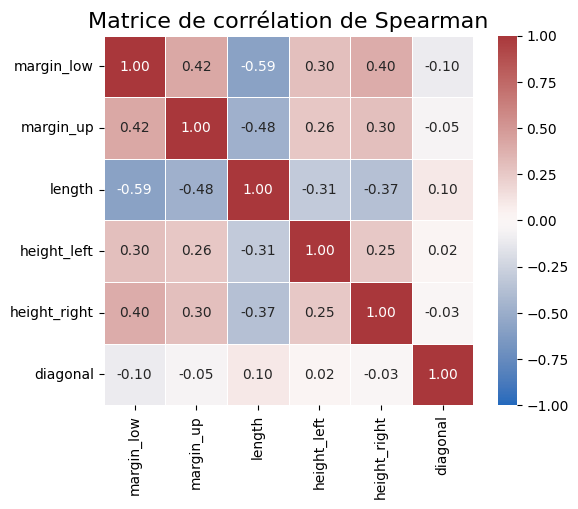

Image enregistrée dans le dossier etude_output.


In [242]:
# Matrice de corrélation de spearman
correlation_spearman = df_analyse[variables_num].corr(method='spearman')

# Heatsmap de la matrice de corrélation de Spearman
sns.heatmap(
    correlation_spearman,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    vmin=-1, vmax=1,
    cbar=True,
    square=True,
    linewidths=0.5,
    linecolor="white"
)
plt.title("Matrice de corrélation de Spearman", fontsize=16)
plt.savefig(f"{OUTPUT_FOLDER}/exploration_matrice_correlation_spearman.png")
plt.show()

print(f"Image enregistrée dans le dossier {OUTPUT_FOLDER}.")

<div style="border: 1px solid white;background-color: rgb(47, 132, 171)" >
<h2 style="margin: auto; padding: 20px ; color : white">ETAPE 4 : PRE-TRAITEMENT</h2>
</div>

<div style="border: 1px solid orange;" >
<h3 style="margin: auto; padding: 20px; ">4.1 Data selection</h3>
</div>

In [243]:
#df_modelisation = df_analyse[variables_num + ["is_genuine"]].copy()
df_modelisation = df_final.copy()

<div style="border: 1px solid orange;" >
<h3 style="margin: auto; padding: 20px; ">4.2 Data split</h3>
</div>

##### Choix des features et target

D'abord, il faut séparer les variables explicatives et la cible :  
- X = les mesures du billet (longueur, hauteur, diagonales…)  
- y = l’étiquette (vrai ou faux)  

Pourquoi ? Parce que le modèle doit apprendre à prédire y en fonction de X.  

In [244]:
features = ["margin_low", "margin_up", "length", "height_left", "height_right", "diagonal"] # Toutes les  de dimensions géométriques
target = "is_genuine" # La colonne cible

In [245]:
X = df_modelisation[features]
y = df_modelisation[target]

##### Train / Test split

In [246]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

##### Scaling

In [247]:
# Instanciation du scaler pour la normalisation des données
scaler = StandardScaler()

# On fit uniquement sur X_train pour éviter la fuite de données (data leakage)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) # transform seulement, pas de fit

print("Données normalisées :")
print(X_train_scaled[:5])  # Affiche les 5 premières lignes des données normalisées

# Vérification de la normalisation en affichant les moyennes et écarts-types des colonnes normalisées
print("\nMoyennes des colonnes normalisées :")
print(X_train_scaled.mean(axis=0))
print("\nÉcarts-types des colonnes normalisées :")
print(X_train_scaled.std(axis=0))
print("\nMoyenne et écart-type de X_train_scaled :\n", X_train_scaled.mean(), X_train_scaled.std())

Données normalisées :
[[-0.59 -0.31  0.65  1.96 -0.37  1.05]
 [-0.59 -1.43  0.92  1.56 -1.32 -0.19]
 [ 0.62  0.86 -0.6   1.    2.12 -1.06]
 [ 1.73  0.51 -1.23  0.83  1.2   0.33]
 [-0.44 -1.13  0.72  1.29 -0.98  0.47]]

Moyennes des colonnes normalisées :
[-0.  0. -0. -0.  0.  0.]

Écarts-types des colonnes normalisées :
[1. 1. 1. 1. 1. 1.]

Moyenne et écart-type de X_train_scaled :
 5.844707434082213e-16 0.9999999999999999


<div style="border: 1px solid white;background-color: rgb(47, 132, 171)" >
<h2 style="margin: auto; padding: 20px ; color : white">ETAPE 5 : MODELISATION</h2>
</div>

<div style="border: 1px solid orange;" >
<h3 style="margin: auto; padding: 20px; ">5.1 Tests de différents modèles</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h4 style="margin: auto; padding: 20px">5.1.1 - Régression logistique (RL)</h4>
</div>

##### Ressources

* [StatQuest: Logistic Regression](https://www.youtube.com/watch?v=yIYKR4sgzI8)

##### Copie des données pour la régression logistique

In [248]:
X_train_rl = X_train_scaled.copy()
y_train_rl = y_train.copy()
X_test_rl = X_test_scaled.copy()
y_test_rl = y_test.copy()

##### Instanciation du modèle + fit

In [249]:
# Initialisation et entraînement en une ligne
clf_rl = LogisticRegression(max_iter=1000, random_state=42).fit(X_train_rl, y_train_rl)

##### Prédictions

In [250]:
# Prédictions finales sur l'ensemble de test
y_pred_rl = clf_rl.predict(X_test_rl)

##### Distribution des probabilités du modèle

In [251]:
# Probabilités prédites pour la classe positive
y_proba_rl = clf_rl.predict_proba(X_test_rl)[:,1]

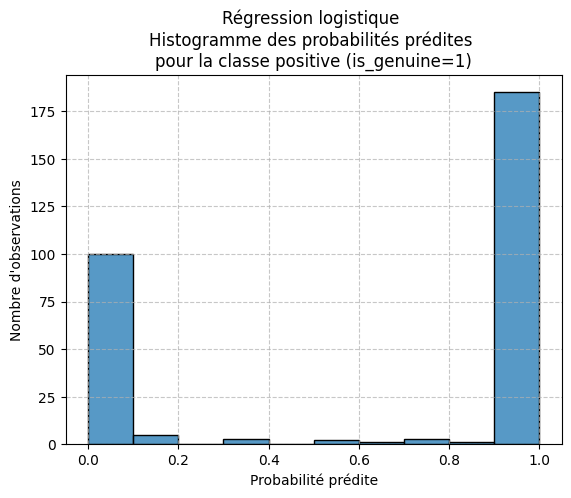

Image enregistrée dans le dossier etude_output.


In [58]:
sns.histplot(y_proba_rl)

plt.title("Régression logistique \nHistogramme des probabilités prédites \npour la classe positive (is_genuine=1)")
plt.xlabel("Probabilité prédite")
plt.ylabel("Nombre d'observations")
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig(f"{OUTPUT_FOLDER}/RegLog_histogramme_probabilites_predites.png")
plt.show()

print(f"Image enregistrée dans le dossier {OUTPUT_FOLDER}.")

##### Métriques

In [59]:
print(classification_report(y_test_rl, y_pred_rl))

              precision    recall  f1-score   support

       False       1.00      0.98      0.99       110
        True       0.99      1.00      0.99       190

    accuracy                           0.99       300
   macro avg       0.99      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300



In [60]:
# Métriques
print("\n--- Performances Régression Logistique ---")
print(f"Accuracy  : {accuracy_score(y_test_rl, y_pred_rl):.4f}") # (TP + TN) / tout
print(f"Précision : {precision_score(y_test_rl, y_pred_rl):.4f}") # TP / (TP + FP)
print(f"Rappel    : {recall_score(y_test_rl, y_pred_rl):.4f}") # TP / (TP + FN)
print(f"F1-score  : {f1_score(y_test_rl, y_pred_rl):.4f}") # 2 * (Précision * Rappel) / (Précision + Rappel)
print(f"ROC-AUC   : {roc_auc_score(y_test_rl, clf_rl.predict_proba(X_test_rl)[:, 1]):.4f}") # AUC du ROC


--- Performances Régression Logistique ---
Accuracy  : 0.9933
Précision : 0.9896
Rappel    : 1.0000
F1-score  : 0.9948
ROC-AUC   : 0.9999


##### Matrice de confusion

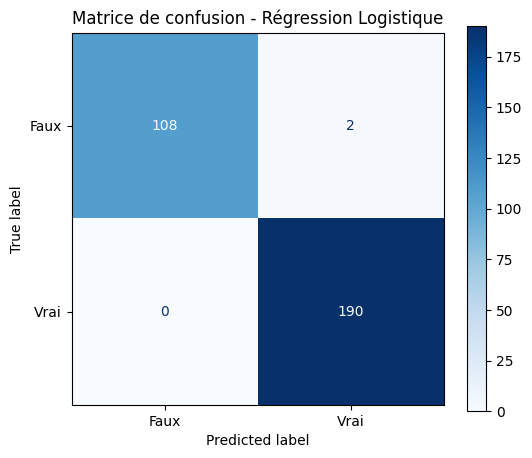

Image enregistrée dans le dossier etude_output.


In [61]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test_rl, y_pred_rl, display_labels=["Faux", "Vrai"], ax=ax, cmap="Blues")
ax.set_title("Matrice de confusion - Régression Logistique")
plt.savefig(f"{OUTPUT_FOLDER}/RegLog_confusion_matrix.png")
plt.show()

print(f"Image enregistrée dans le dossier {OUTPUT_FOLDER}.")

##### Courbe ROC

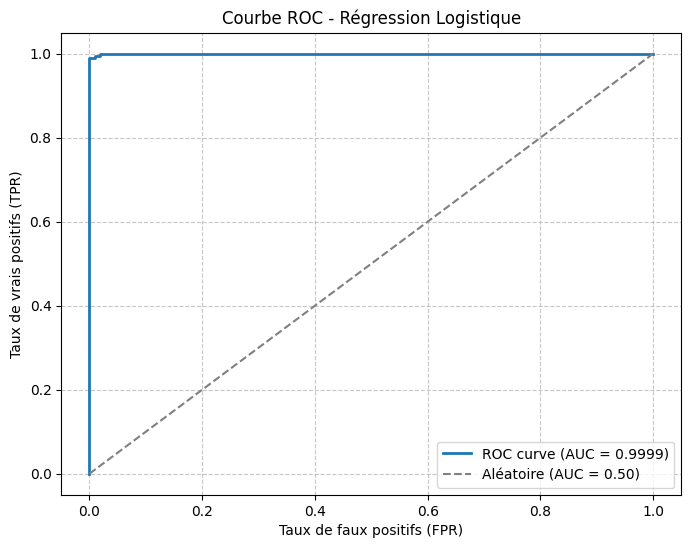

Image enregistrée dans le dossier etude_output.


In [62]:
# Calcul de la courbe
fpr_rl, tpr_rl, seuils_rl = roc_curve(y_test_rl, y_proba_rl)
roc_auc_rl = auc(fpr_rl, tpr_rl)

# Affichage de la courbe ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr_rl, tpr_rl, lw=2, label=f"ROC curve (AUC = {roc_auc_rl:.4f})")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--", label="Aléatoire (AUC = 0.50)")
plt.xlabel("Taux de faux positifs (FPR)")
plt.ylabel("Taux de vrais positifs (TPR)")
plt.title("Courbe ROC - Régression Logistique")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig(f"{OUTPUT_FOLDER}/RegLog_roc_curve.png")
plt.show()

print(f"Image enregistrée dans le dossier {OUTPUT_FOLDER}.")

<div style="border: 1px solid RGB(51,165,182);" >
<h4 style="margin: auto; padding: 20px">5.1.2 - K-nearest neighbors (KNN)</h4>
</div>

##### Ressources

* [StatQuest: K-nearest neighbors, Clearly Explained](https://youtu.be/HVXime0nQeI)

##### Copie des données pour le KNN

In [63]:
X_train_knn = X_train_scaled.copy()
y_train_knn = y_train.copy()
X_test_knn = X_test_scaled.copy()
y_test_knn = y_test.copy()

##### Recherche du meilleur k par validation croisée

In [64]:
k_scores = []
k_range = range(1, 21)

print("Scores moyens accuracy pour différents k :\n")

for k in k_range:
    knn_tmp = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn_tmp, X_train_knn, y_train_knn, cv=5, scoring="accuracy") # 5 folds
    k_scores.append(scores.mean())
    print(f"k = {k} ; score moyen accuracy = {scores.mean():.4f}")

print("--------------------------------")
best_k = k_range[np.argmax(k_scores)]
print(f"Meilleur k trouvé par validation croisée : \nk={best_k} avec score moyen accuracy = {max(k_scores):.4f}")

Scores moyens accuracy pour différents k :

k = 1 ; score moyen accuracy = 0.9858
k = 2 ; score moyen accuracy = 0.9833
k = 3 ; score moyen accuracy = 0.9900
k = 4 ; score moyen accuracy = 0.9883
k = 5 ; score moyen accuracy = 0.9900
k = 6 ; score moyen accuracy = 0.9908
k = 7 ; score moyen accuracy = 0.9917
k = 8 ; score moyen accuracy = 0.9908
k = 9 ; score moyen accuracy = 0.9908
k = 10 ; score moyen accuracy = 0.9917
k = 11 ; score moyen accuracy = 0.9908
k = 12 ; score moyen accuracy = 0.9892
k = 13 ; score moyen accuracy = 0.9917
k = 14 ; score moyen accuracy = 0.9900
k = 15 ; score moyen accuracy = 0.9900
k = 16 ; score moyen accuracy = 0.9908
k = 17 ; score moyen accuracy = 0.9908
k = 18 ; score moyen accuracy = 0.9900
k = 19 ; score moyen accuracy = 0.9900
k = 20 ; score moyen accuracy = 0.9908
--------------------------------
Meilleur k trouvé par validation croisée : 
k=7 avec score moyen accuracy = 0.9917


##### Accuracy en fonction de k

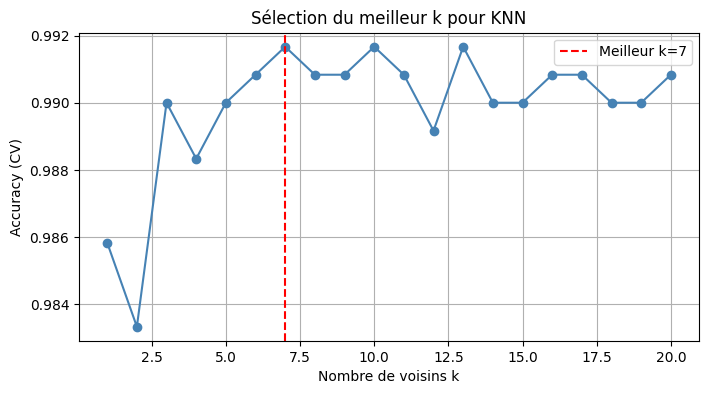

Image enregistrée dans le dossier etude_output.


In [65]:
plt.figure(figsize=(8, 4))
plt.plot(k_range, k_scores, marker="o", color="steelblue")
plt.axvline(best_k, color="red", linestyle="--", label=f"Meilleur k={best_k}")
plt.xlabel("Nombre de voisins k")
plt.ylabel("Accuracy (CV)")
plt.title("Sélection du meilleur k pour KNN")
plt.legend()
plt.grid(True)
plt.savefig(f"{OUTPUT_FOLDER}/KNN_best_k_selection.png")
plt.show()

print(f"Image enregistrée dans le dossier {OUTPUT_FOLDER}.")

##### Instanciation du modèle avec le meilleur k + fit

In [66]:
clf_knn = KNeighborsClassifier(n_neighbors=best_k).fit(X_train_knn, y_train_knn)

##### Prédictions

In [67]:
# Prédiction sur l'ensemble de test
y_pred_knn = clf_knn.predict(X_test_knn)

##### Distribution des probabilités du modèle

In [68]:
# Probabilités prédites pour la classe positive (True)
y_proba_knn = clf_knn.predict_proba(X_test_knn)[:, 1]

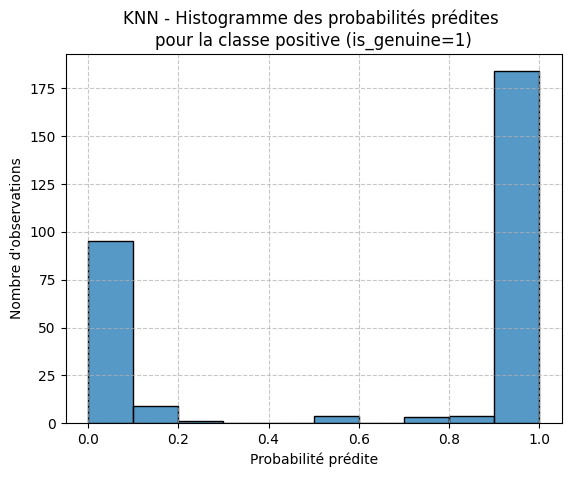

Image enregistrée dans le dossier etude_output.


In [69]:
sns.histplot(y_proba_knn)

plt.title("KNN - Histogramme des probabilités prédites \npour la classe positive (is_genuine=1)")
plt.xlabel("Probabilité prédite")
plt.ylabel("Nombre d'observations")
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig(f"{OUTPUT_FOLDER}/KNN_histogramme_probabilites_predites.png")
plt.show()

print(f"Image enregistrée dans le dossier {OUTPUT_FOLDER}.")

##### Métriques

In [70]:
print("--- Performances KNN ---")
print(f"Accuracy  : {accuracy_score(y_test_knn, y_pred_knn):.4f}") # (TP + TN) / tout
print(f"Précision : {precision_score(y_test_knn, y_pred_knn):.4f}") # TP / (TP + FP)
print(f"Rappel    : {recall_score(y_test_knn, y_pred_knn):.4f}") # TP / (TP + FN)
print(f"F1-score  : {f1_score(y_test_knn, y_pred_knn):.4f}") # 2 * (Précision * Rappel) / (Précision + Rappel)
print(f"ROC-AUC   : {roc_auc_score(y_test_knn, clf_knn.predict_proba(X_test_knn)[:, 1]):.4f}") # AUC du ROC

--- Performances KNN ---
Accuracy  : 0.9833
Précision : 0.9744
Rappel    : 1.0000
F1-score  : 0.9870
ROC-AUC   : 0.9953


##### Matrice de confusion

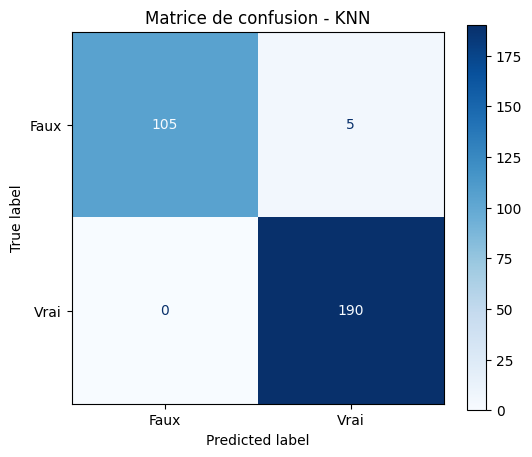

Image enregistrée dans le dossier etude_output.


In [71]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test_knn, y_pred_knn, display_labels=['Faux', 'Vrai'], ax=ax, cmap='Blues')
ax.set_title('Matrice de confusion - KNN')
plt.savefig(f"{OUTPUT_FOLDER}/KNN_confusion_matrix.png")
plt.show()

print(f"Image enregistrée dans le dossier {OUTPUT_FOLDER}.")

##### Courbe ROC

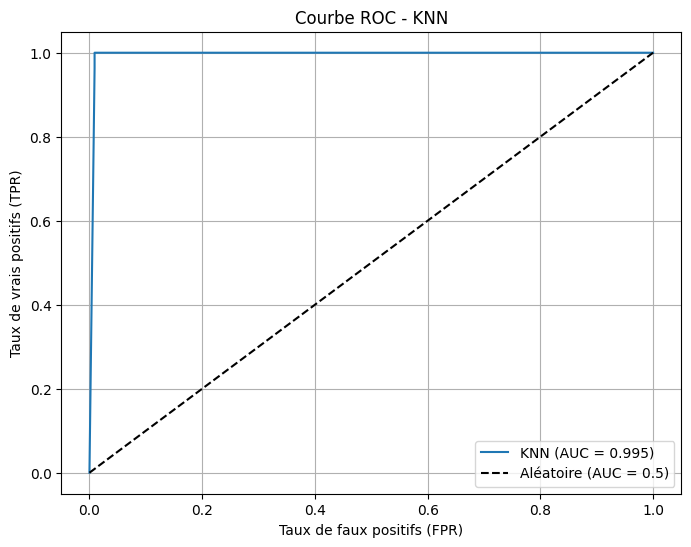

Image enregistrée dans le dossier etude_output.


In [72]:
# Calcul de la courbe
fpr, tpr, seuils = roc_curve(y_test_knn, y_proba_knn)
auc = roc_auc_score(y_test_knn, y_proba_knn)

# Affichage de la courbe ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"KNN (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Aléatoire (AUC = 0.5)")
plt.xlabel("Taux de faux positifs (FPR)")
plt.ylabel("Taux de vrais positifs (TPR)")
plt.title("Courbe ROC - KNN")
plt.legend()
plt.grid(True)
plt.savefig(f"{OUTPUT_FOLDER}/KNN_roc_curve.png")
plt.show()

print(f"Image enregistrée dans le dossier {OUTPUT_FOLDER}.")

<div style="border: 1px solid RGB(51,165,182);" >
<h4 style="margin: auto; padding: 20px">5.1.3 - RandomForestClassifier (RFC)</h4>
</div>

##### Ressources

* [StatQuest: Random Forests Part 1 - Building, Using and Evaluating](https://youtu.be/J4Wdy0Wc_xQ)
* [StatQuest: Random Forests Part 2: Missing data and clustering](https://www.youtube.com/watch?v=sQ870aTKqiM)

##### Copie des données pour le RFC

In [73]:
X_train_rfc = X_train_scaled.copy()
y_train_rfc = y_train.copy()
X_test_rfc = X_test_scaled.copy()
y_test_rfc = y_test.copy()

##### Recherche du meilleur n_estimators par validation croisée

In [74]:
# Choix du nombre d"arbres pour le Random Forest Classifier
n_range = [10, 50, 100, 200, 500]
n_scores = []

for n in n_range:
    rfc_tmp = RandomForestClassifier(n_estimators=n, random_state=42)
    score = cross_val_score(rfc_tmp, X_train_rfc, y_train_rfc, cv=5, scoring="accuracy")
    n_scores.append(score.mean())
    print(f"n = {n} ; score moyen accuracy = {score.mean():.4f}")

print("--------------------------------")
best_n = n_range[np.argmax(n_scores)]
print(f"Meilleur n trouvé par validation croisée : \nn={best_n} avec score moyen accuracy = {max(n_scores):.4f}")

n = 10 ; score moyen accuracy = 0.9900
n = 50 ; score moyen accuracy = 0.9917
n = 100 ; score moyen accuracy = 0.9925
n = 200 ; score moyen accuracy = 0.9925
n = 500 ; score moyen accuracy = 0.9925
--------------------------------
Meilleur n trouvé par validation croisée : 
n=100 avec score moyen accuracy = 0.9925


##### Accuracy en fonction de n_estimators

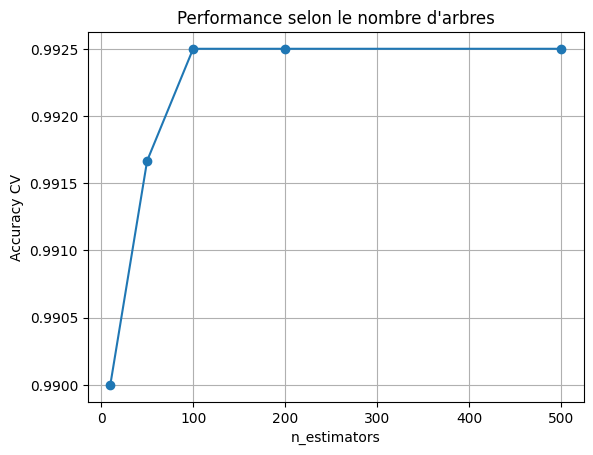

Image enregistrée dans le dossier etude_output.


In [75]:
plt.plot(n_range, n_scores, marker="o")
plt.xlabel("n_estimators")
plt.ylabel("Accuracy CV")
plt.title("Performance selon le nombre d'arbres")
plt.grid(True)
plt.savefig(f"{OUTPUT_FOLDER}/RFC_best_n_selection.png")
plt.show()

print(f"Image enregistrée dans le dossier {OUTPUT_FOLDER}.")

##### Recherche du meilleur max_depth

In [76]:
# Recherche du meilleur hyperparamètre max_depth pour le Random Forest Classifier
# Pour cela, on utilise GridSearchCV pour tester différentes valeurs de max_depth
# et trouver celle qui donne le meilleur score de validation croisée.

param_grid = {
    "max_depth": [3, 5, 10, 20, None]
}

grid_search = GridSearchCV(
    RandomForestClassifier(n_estimators=best_n, random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy"
)

grid_search.fit(X_train_rfc, y_train_rfc)
print(f"Meilleur max_depth : {grid_search.best_params_}")
print(f"Meilleur score CV  : {grid_search.best_score_:.4f}")

best_max_depth = grid_search.best_params_["max_depth"]

Meilleur max_depth : {'max_depth': 10}
Meilleur score CV  : 0.9925


##### Accuracy en fonction de max_depth

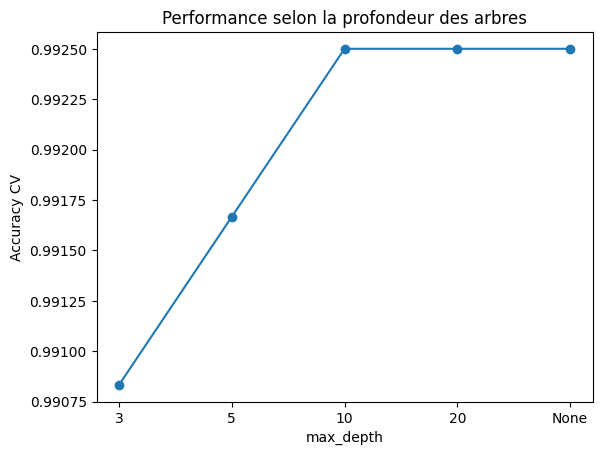

Image enregistrée dans le dossier etude_output.


In [77]:
depth_range = [3, 5, 10, 20, None]
scores = []

for depth in depth_range:
    rfc = RandomForestClassifier(n_estimators=best_n, max_depth=depth, random_state=42)
    score = cross_val_score(rfc, X_train_rfc, y_train_rfc, cv=5, scoring="accuracy")
    scores.append(score.mean())

# Pour l"affichage, on remplace None par une valeur lisible
depth_labels = [str(d) if d is not None else "None" for d in depth_range]

plt.plot(depth_labels, scores, marker="o")
plt.xlabel("max_depth")
plt.ylabel("Accuracy CV")
plt.title("Performance selon la profondeur des arbres")
plt.savefig(f"{OUTPUT_FOLDER}/RFC_best_max_depth_selection.png")
plt.show()

print(f"Image enregistrée dans le dossier {OUTPUT_FOLDER}.")

##### Instanciation du modèle avec les meilleurs paramètres + fit

In [78]:
clf_rfc = RandomForestClassifier(n_estimators=best_n, max_depth=best_max_depth, random_state=42).fit(X_train_rfc, y_train_rfc)

##### Prédictions

In [79]:
y_pred_rfc = clf_rfc.predict(X_test_rfc)

##### Distribution des probabilités du modèle

In [80]:
# Probabilités prédites pour la classe positive (True)
y_proba_rfc = clf_rfc.predict_proba(X_test_rfc)[:, 1]  # proba d"être "True"

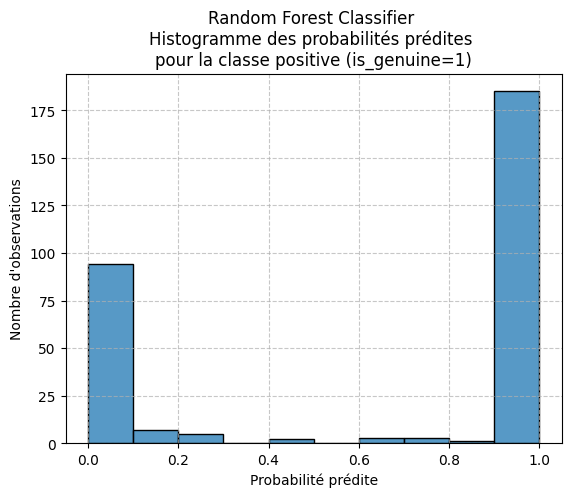

Image enregistrée dans le dossier etude_output.


In [81]:
sns.histplot(y_proba_rfc)

plt.title("Random Forest Classifier \nHistogramme des probabilités prédites \npour la classe positive (is_genuine=1)")
plt.xlabel("Probabilité prédite")
plt.ylabel("Nombre d'observations")
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig(f"{OUTPUT_FOLDER}/RFC_histogramme_probabilites_predites.png")
plt.show()

print(f"Image enregistrée dans le dossier {OUTPUT_FOLDER}.")

##### Métriques

In [82]:
print("--- Performances Random Forest ---")
print(f"Accuracy  : {accuracy_score(y_test_rfc, y_pred_rfc):.4f}")
print(f"Précision : {precision_score(y_test_rfc, y_pred_rfc):.4f}")
print(f"Rappel    : {recall_score(y_test_rfc, y_pred_rfc):.4f}")
print(f"F1-score  : {f1_score(y_test_rfc, y_pred_rfc):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test_rfc, clf_rfc.predict_proba(X_test_rfc)[:, 1]):.4f}")

--- Performances Random Forest ---
Accuracy  : 0.9933
Précision : 0.9896
Rappel    : 1.0000
F1-score  : 0.9948
ROC-AUC   : 0.9999


##### Importance des variables

Variable très utilisée pour trancher → score élevé  
Variable pas très utile              → score faible

C:\Users\tphnr\AppData\Local\Temp\ipykernel_2352\269563111.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x=feat_imp.values, y=feat_imp.index, palette="Blues_r", ax=axes[0])


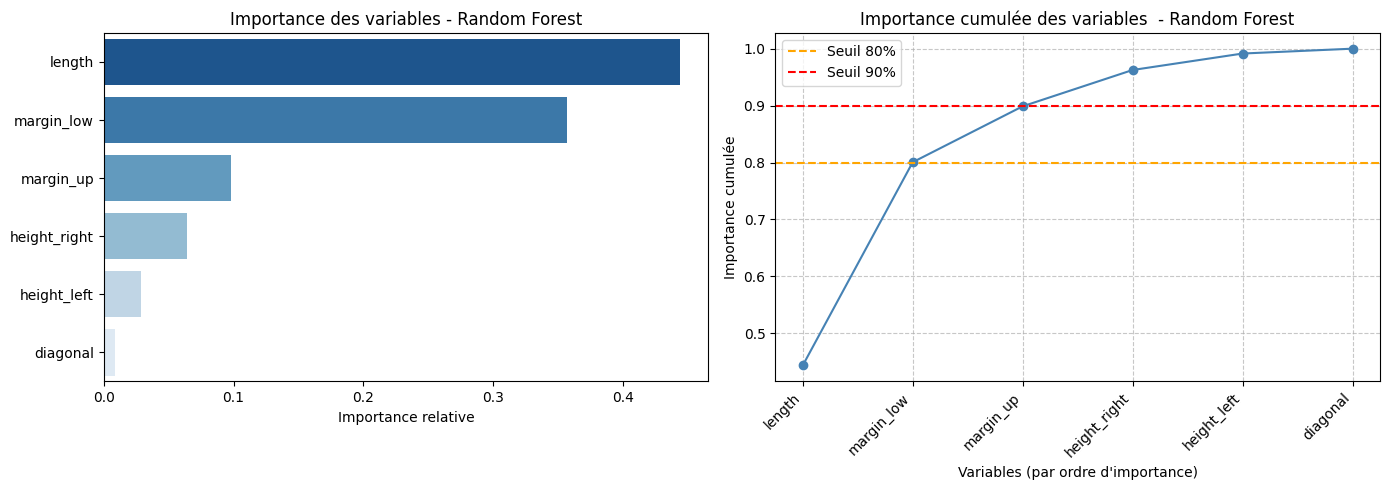

Image enregistrée dans le dossier etude_output.


In [83]:
feat_imp = pd.Series(clf_rfc.feature_importances_, index=variables_num).sort_values(ascending=False)
rfc_cumsum = feat_imp.cumsum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique 1 : importance des variables avec étiquettes
bars = sns.barplot(x=feat_imp.values, y=feat_imp.index, palette="Blues_r", ax=axes[0])

axes[0].set_title("Importance des variables - Random Forest")
axes[0].set_xlabel("Importance relative")
axes[0].set_ylabel("")
axes[0].set_xlim(0, feat_imp.values[0] * 1.05)  # petite marge à droite

# Graphique 2 : cumul
axes[1].plot(range(1, len(rfc_cumsum) + 1), rfc_cumsum.values, marker="o", color="steelblue")
axes[1].axhline(y=0.8, color="orange", linestyle="--", label="Seuil 80%")
axes[1].axhline(y=0.9, color="red",    linestyle="--", label="Seuil 90%")
axes[1].set_xticks(range(1, len(rfc_cumsum) + 1))
axes[1].set_xticklabels(rfc_cumsum.index, rotation=45, ha="right")
axes[1].set_title("Importance cumulée des variables  - Random Forest")
axes[1].set_xlabel("Variables (par ordre d'importance)")
axes[1].set_ylabel("Importance cumulée")
axes[1].legend()

plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.savefig(f"{OUTPUT_FOLDER}/RFC_feature_importance.png")
plt.show()

print(f"Image enregistrée dans le dossier {OUTPUT_FOLDER}.")

In [84]:
# Afficher le cumul pour voir combien de variables suffisent
feat_imp_cumul = feat_imp.cumsum()
print(feat_imp_cumul)

length          0.443527
margin_low      0.800564
margin_up       0.898753
height_right    0.962536
height_left     0.991458
diagonal        1.000000
dtype: float64


##### Matrice de confusion

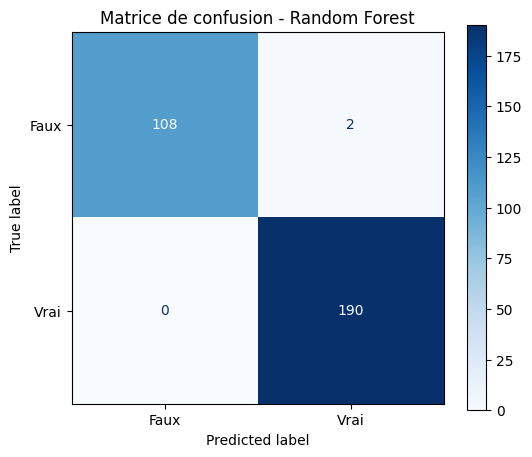

Image enregistrée dans le dossier etude_output.


In [85]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test_rfc, y_pred_rfc, display_labels=["Faux", "Vrai"], ax=ax, cmap="Blues")
ax.set_title("Matrice de confusion - Random Forest")
plt.savefig(f"{OUTPUT_FOLDER}/RFC_confusion_matrix.png")
plt.show()

print(f"Image enregistrée dans le dossier {OUTPUT_FOLDER}.")

##### Courbe ROC

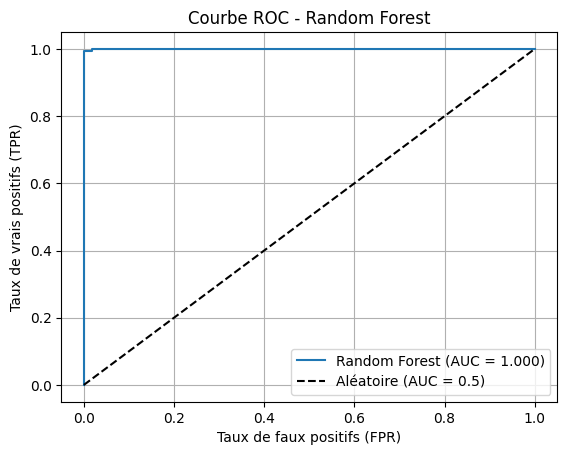

Image enregistrée dans le dossier etude_output.


In [86]:
# Calcul de la courbe
fpr, tpr, seuils = roc_curve(y_test_rfc, y_proba_rfc)
auc = roc_auc_score(y_test_rfc, y_proba_rfc)

# Affichage de la courbe ROC
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Aléatoire (AUC = 0.5)")
plt.xlabel("Taux de faux positifs (FPR)")
plt.ylabel("Taux de vrais positifs (TPR)")
plt.title("Courbe ROC - Random Forest")
plt.legend()
plt.grid(True)
plt.savefig(f"{OUTPUT_FOLDER}/RFC_roc_curve.png")
plt.show()

print(f"Image enregistrée dans le dossier {OUTPUT_FOLDER}.")

<div style="border: 1px solid RGB(51,165,182);" >
<h4 style="margin: auto; padding: 20px">5.1.4 - Kmeans</h4>
</div>

##### Point d'attention

Le K-means est un algorithme de **clustering non supervisé** : il ne connaît pas les étiquettes 
(vrai/faux billet) et va simplement regrouper les données en 2 groupes selon leur similarité.

C'est une différence fondamentale avec les modèles utilisés précédemment , qui sont des algorithmes supervisés de classification.  
K-means n'utilise pas de `y_train`, ne prédit pas de classe directement, et ne fournit pas de probabilité de classe.  
L'association cluster → vrai/faux billet doit être faite manuellement après l'entraînement.

**Pertinence pour ce projet : limitée.**
Puisque les étiquettes sont disponibles, un modèle supervisé sera toujours plus adapté.  
K-means est présenté ici uniquement pour vérifier que les données forment naturellement 2 groupes distincts.

##### Ressources

* [StatQuest: K-means clustering](https://youtu.be/4b5d3muPQmA)

##### Copie des données pour le Kmeans (KM)

In [87]:
X_train_km = X_train_scaled.copy()
X_test_km = X_test_scaled.copy()
y_test_km = y_test.copy()

##### Vérification n_clusters avec méthode du coude

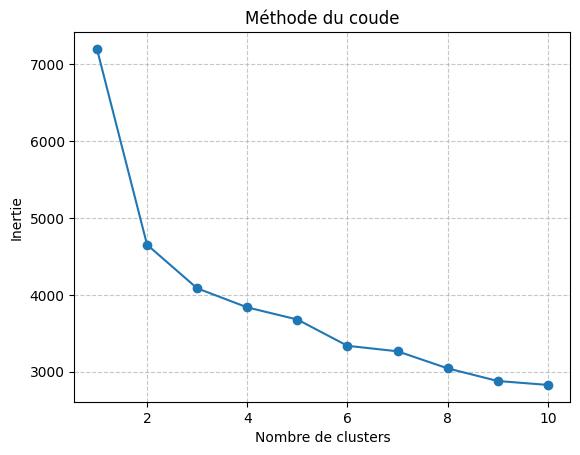

Image enregistrée dans le dossier etude_output.


In [88]:
# Vérification graphique choix n_clusters avec méthode du coude (Elbow Method)

inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_train_km)
    inertia.append(kmeans.inertia_)


plt.plot(range(1, 11), inertia, marker="o")
plt.title("Méthode du coude")
plt.xlabel("Nombre de clusters")
plt.ylabel("Inertie")
plt.grid(True, linestyle="--", alpha=0.7)
plt.savefig(f"{OUTPUT_FOLDER}/KMeans_elbow_method.png")
plt.show()

print(f"Image enregistrée dans le dossier {OUTPUT_FOLDER}.")

##### Instanciation du modèle et fit

On choisit n_clusters = 2 car on sait déjà qu'il n'y a que 2 classes : la target is_genuine est composée de Vrai ou Faux. 

In [89]:
km = KMeans(n_clusters=2, random_state=42).fit(X_train_km)

##### Propriétés du modèle

In [90]:
print("Centres des clusters :")
print(km.cluster_centers_)
print("---" * 10)
print("Labels des clusters :")
print(km.labels_)
print("---" * 10)
print("Inertie (somme des distances au carré aux centres) :")
print(km.inertia_)

Centres des clusters :
[[ 1.15  0.89 -1.25  0.56  0.73 -0.19]
 [-0.54 -0.41  0.58 -0.26 -0.34  0.09]]
------------------------------
Labels des clusters :
[1 1 0 ... 1 0 0]
------------------------------
Inertie (somme des distances au carré aux centres) :
4652.309447047173


##### Prédictions

In [91]:
clusters_test = km.predict(X_test_km)

##### Identification des clusters

In [92]:
# K-means assigne des numéros de clusters (0 ou 1) sans savoir ce qu'ils représentent.
# On doit donc identifier manuellement quel cluster correspond aux vrais/faux billets,
# en regardant quelle classe est majoritaire dans chaque cluster.

# On transforme classe réelle True/False en nombre entier 1/0 (classe réelle)
y_test_int = y_test_km.astype(int).values # (equivalent de is_genuine_num)

# Dictionnaire vide qui va stocker correspondance n° de cluster et classe réelle.
mapping = {}

for cluster_id in [0, 1]:
    points_du_cluster = y_test_int[clusters_test == cluster_id]
    mapping[cluster_id] = mode(points_du_cluster, keepdims=True).mode[0]

# Exemple : si cluster 0 contient majoritairement des vrais billets alors mapping = {0: 1, 1: 0}
print("Correspondance clusters → classes :", mapping)

# Traduction de chaque numéro de cluster en classe réelle
y_pred_km = np.array([mapping[c] for c in clusters_test])

Correspondance clusters → classes : {0: np.int64(0), 1: np.int64(1)}


##### Métriques

In [93]:
accuracy_km = accuracy_score(y_test_int, y_pred_km)
ari = adjusted_rand_score(y_test_int, clusters_test)
silhouette = silhouette_score(X_test_km, clusters_test)

print("--- Performances KMeans (clustering non supervisé) ---")
print(f"Accuracy (après mapping)  : {accuracy_km:.4f}  (comparaison avec les modèles supervisés)")
print(f"Adjusted Rand Index       : {ari:.4f}  (1=parfait, 0=aléatoire)")
print(f"Silhouette Score          : {silhouette:.4f}  (1=clusters compacts, 0=chevauchement)")

--- Performances KMeans (clustering non supervisé) ---
Accuracy (après mapping)  : 0.9900  (comparaison avec les modèles supervisés)
Adjusted Rand Index       : 0.9601  (1=parfait, 0=aléatoire)
Silhouette Score          : 0.3368  (1=clusters compacts, 0=chevauchement)


##### Visualisation des clusters en 2D : Méthode

Les données comportent 6 features, ce qui les rend impossibles à visualiser directement.  
On utilise une **ACP (Analyse en Composantes Principales)** pour réduire ces 6 dimensions,
tout en conservant un maximum d'information.

La démarche est la suivante :
1. **Scree plot** : vérifier si 2 composantes suffisent à représenter fidèlement les données
2. **Graphique comparatif** : visualiser côte à côte les clusters K-means vs les vraies classes

Si les deux graphiques se ressemblent, K-means a bien séparé les deux groupes.

##### Choix du nombre de composantes

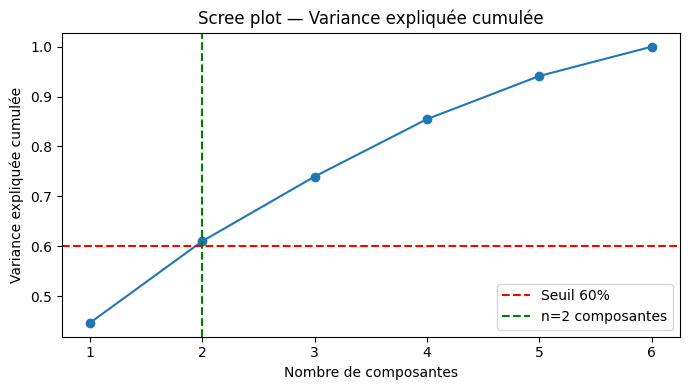

Image enregistrée dans le dossier etude_output.


In [94]:
pca_full = PCA()
pca_full.fit(X_test_km)

variance_cumulee = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(7, 4))
plt.plot(range(1, len(variance_cumulee) + 1), variance_cumulee, marker="o")
plt.axhline(y=0.60, color="red", linestyle="--", label="Seuil 60%")
plt.axvline(x=2, color="green", linestyle="--", label="n=2 composantes")
plt.xlabel("Nombre de composantes")
plt.ylabel("Variance expliquée cumulée")
plt.title("Scree plot — Variance expliquée cumulée")
plt.legend()
plt.tight_layout()
plt.savefig(f"{OUTPUT_FOLDER}/KMeans_Scree_plot")
plt.show()

print(f"Image enregistrée dans le dossier {OUTPUT_FOLDER}.")

In [95]:
variance_expliquee = pca_full.explained_variance_ratio_
print(f"Total expliqué par PC1+PC2 : {variance_expliquee[0]+variance_expliquee[1]:.2%}")

Total expliqué par PC1+PC2 : 61.01%


##### Visualisation des clusters

In [96]:
# ACP avec deux composantes
pca = PCA(n_components=2)
X_test_2d = pca.fit_transform(X_test_km)

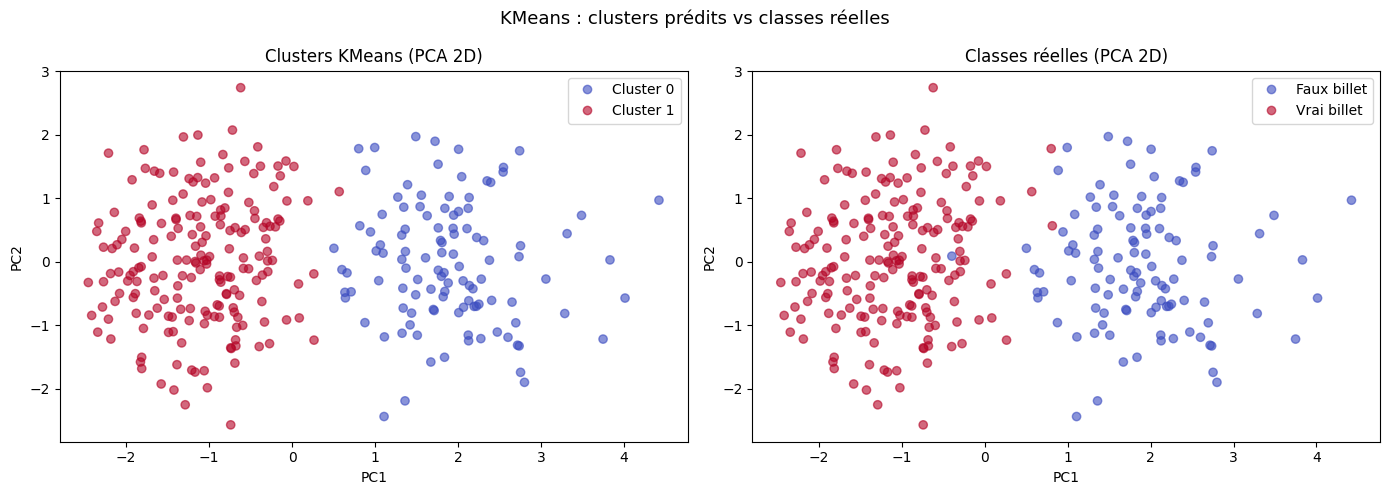

Image enregistrée dans le dossier etude_output.


In [97]:
# Comparaison graphique des clusters K-means et des classes réelles sur les deux premières composantes principales

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique 1 : Clusters K-means
scatter1 = axes[0].scatter(X_test_2d[:,0], X_test_2d[:,1], c=clusters_test, cmap="coolwarm", alpha=0.6)
axes[0].set_title("Clusters KMeans (PCA 2D)")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
handles1, _ = scatter1.legend_elements()
axes[0].legend(handles1, ["Cluster 0", "Cluster 1"])

# Graphique 2 : Classes réelles
scatter2 = axes[1].scatter(X_test_2d[:,0], X_test_2d[:,1], c=y_test_int, cmap="coolwarm", alpha=0.6)
axes[1].set_title("Classes réelles (PCA 2D)")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
handles2, _ = scatter2.legend_elements()
axes[1].legend(handles2, ["Faux billet", "Vrai billet"])

plt.suptitle("KMeans : clusters prédits vs classes réelles", fontsize=13)
plt.tight_layout()
plt.savefig(f"{OUTPUT_FOLDER}/KMeans_PCA_2D.png")
plt.show()

print(f"Image enregistrée dans le dossier {OUTPUT_FOLDER}.")

##### Matrice de confusion

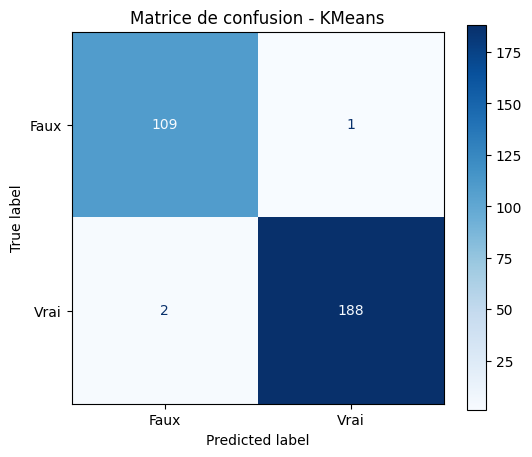

Image enregistrée dans le dossier etude_output.


In [98]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test_int, y_pred_km, display_labels=["Faux", "Vrai"], ax=ax, cmap="Blues")
ax.set_title("Matrice de confusion - KMeans")
plt.savefig(f"{OUTPUT_FOLDER}/KMeans_confusion_matrix.png")
plt.show()

print(f"Image enregistrée dans le dossier {OUTPUT_FOLDER}.")

<div style="border: 1px solid orange;" >
<h3 style="margin: auto; padding: 20px; ">5.2 Sélection du meilleur modèle</h3>
</div>

##### Ressources

Mais alors, quel est le meilleur modèle pour résoudre ce problème ?

Pour répondre à cette question, il vous faut bien comprendre l'intérêt de chacune des métriques d'évaluation qui existent pour ce type de problème.

* [Machine Learning Fundamentals: Sensitivity and Specificity
](https://youtu.be/vP06aMoz4v8)
* [Machine Learning Fundamentals: The Confusion Matrix](https://youtu.be/Kdsp6soqA7o)
* [ROC and AUC, Clearly Explained!](https://youtu.be/4jRBRDbJemM)

Modules sur Sklearn :
* [Confusion Matrix](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html)
* [Confusion Matrix Display](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html)
* [Classification Report](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html)


##### Regroupement des modèles

In [99]:
# Définition des modèles et de leurs données d'entraînement
# On utilise uniquement le set test pour comparer
# Remarque : kmean exlu.

models = {
    "Régression Logistique": (clf_rl, X_test_rl, y_test_rl, y_pred_rl, y_proba_rl),
    "KNN": (clf_knn, X_test_knn, y_test_knn, y_pred_knn, y_proba_knn),
    "Random Forest": (clf_rfc, X_test_rfc, y_test_rfc, y_pred_rfc, y_proba_rfc),
}

##### Comparaison des métriques de chaque modèle

In [100]:
# On va comparer les modèles sur plusieurs métriques : Accuracy, Précision, Rappel, F1-score et ROC-AUC
results = []

for name, (model, X_test, y_test, y_pred, y_proba) in models.items():
    results.append({
        "Modèle": name,
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "Précision": round(precision_score(y_test, y_pred), 4),
        "Rappel": round(recall_score(y_test, y_pred), 4),
        "F1-score": round(f1_score(y_test, y_pred), 4),
        "ROC-AUC": round(roc_auc_score(y_test, y_proba), 4),
    })

df_results = pd.DataFrame(results).set_index("Modèle")
print("---Tableau récapitulatif des métriques de chaque modèle ---")
display(df_results)

---Tableau récapitulatif des métriques de chaque modèle ---


,Accuracy,Précision,Rappel,F1-score,ROC-AUC
Modèle,,,,,
Régression Logistique,0.9933,0.9896,1.0,0.9948,0.9999
KNN,0.9833,0.9744,1.0,0.9870,0.9953
Random Forest,0.9933,0.9896,1.0,0.9948,0.9999


In [101]:
def highlight_max(s):
    is_max = s == s.max()
    return ["background-color: darkgreen" if v else "" for v in is_max]


styled_df = (
    df_results.style
    .apply(highlight_max, axis=0)
    .format("{:.4f}")
)

print("--- Comparaison des modèles (valeurs maximales en vert) ---")
display(styled_df)

--- Comparaison des modèles (valeurs maximales en vert) ---


,Accuracy,Précision,Rappel,F1-score,ROC-AUC
Modèle,,,,,
Régression Logistique,0.9933,0.9896,1.0000,0.9948,0.9999
KNN,0.9833,0.9744,1.0000,0.9870,0.9953
Random Forest,0.9933,0.9896,1.0000,0.9948,0.9999


##### Comparatif : Courbes ROC

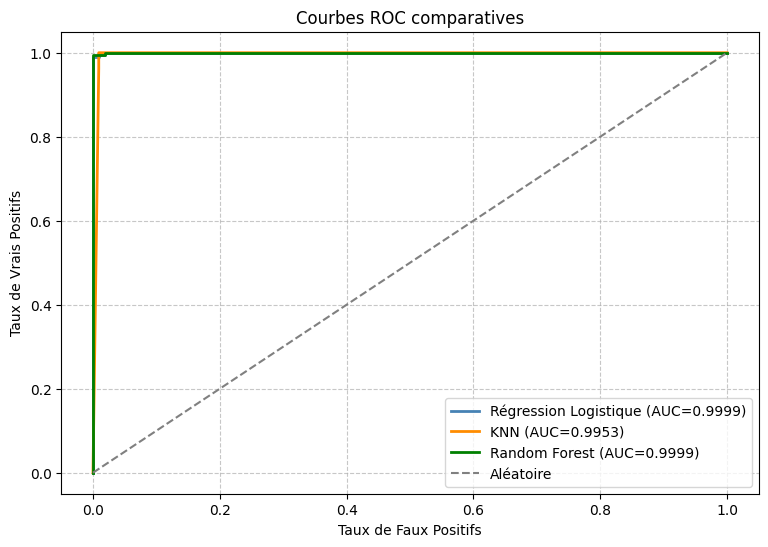

Image enregistrée dans le dossier etude_output.


In [102]:
plt.figure(figsize=(9, 6))
colors = ["steelblue", "darkorange", "green"]

for (name, (model, X_test, y_test, y_pred, y_proba)), color in zip(models.items(), colors):
    fpr_, tpr_, _ = roc_curve(y_test, model.predict_proba(X_test)[:, 1])
    auc_ = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    plt.plot(fpr_, tpr_, color=color, lw=2, label=f"{name} (AUC={auc_:.4f})")

plt.plot([0,1],[0,1],"--",color="gray",label="Aléatoire")
plt.xlabel("Taux de Faux Positifs")
plt.ylabel("Taux de Vrais Positifs")
plt.title("Courbes ROC comparatives")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.7)
plt.savefig(f"{OUTPUT_FOLDER}/Comparaison_ROC_curves.png")
plt.show()

print(f"Image enregistrée dans le dossier {OUTPUT_FOLDER}.")

##### Comparatif : Matrices de confusion

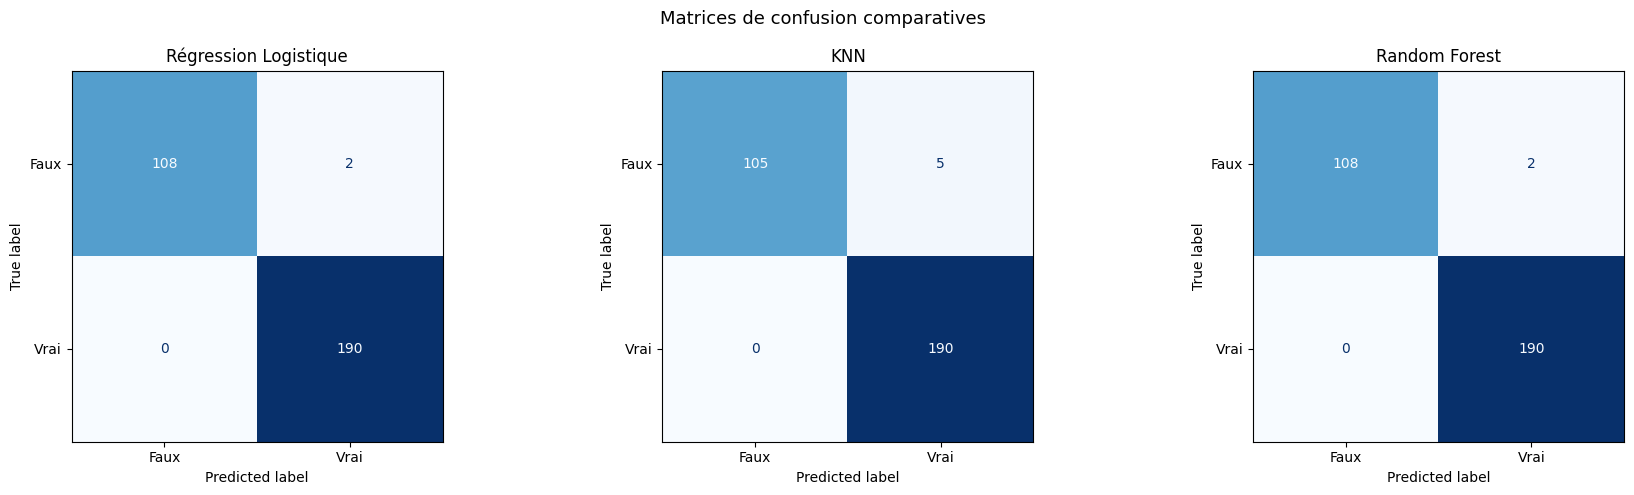

Image enregistrée dans le dossier etude_output.


In [103]:
# Matrices de confusion côte à côte
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, (model, X_test, y_test, y_pred, y_proba)) in zip(axes, models.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test, model.predict(X_test),
        display_labels=["Faux", "Vrai"],
        ax=ax, colorbar=False, cmap="Blues"
    )
    ax.set_title(name)

plt.suptitle("Matrices de confusion comparatives", fontsize=13)
plt.tight_layout()
plt.savefig(f"{OUTPUT_FOLDER}/Comparaison_confusion_matrix.png")
plt.show()

print(f"Image enregistrée dans le dossier {OUTPUT_FOLDER}.")

##### Choix du meilleur modèle

Les meilleurs modèles sont la régression logistique ainsi que le Random Forest.  
Ils ont des résultats équivalents.  
Pour les départager, on va alors se baser sur un autre critère : **l'explicabilité.**  
**→ La régression logistique l'emporte alors.**

In [104]:
best_model_name = "Régression Logistique"
best_model = models[best_model_name]

##### Classification Report du meilleur modèle

In [105]:
best_m, best_Xt, best_yt, best_pred, best_proba = models[best_model_name]
print(f"--- Classification report : {best_model_name} ---")
from sklearn.metrics import classification_report
print(classification_report(best_yt, best_m.predict(best_Xt), target_names=["Faux billet", "Vrai billet"]))

--- Classification report : Régression Logistique ---
              precision    recall  f1-score   support

 Faux billet       1.00      0.98      0.99       110
 Vrai billet       0.99      1.00      0.99       190

    accuracy                           0.99       300
   macro avg       0.99      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300



<div style="border: 1px solid orange;" >
<h3 style="margin: auto; padding: 20px; ">5.3 Sauvegarde du meilleur modèle</h3>
</div>

##### Ressources

```
Sauvegarder un modèle implique de sauvegarder aussi les étapes de préprocessing des données.
→ à minima, StandardScaler.
```
Voir [`make_pipeline`](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.make_pipeline.html) pour plus d'infos.

##### Sauvegarde

In [106]:
# Utilisez make_pipeline pour inclure toutes les étapes nécessaires
# à la prédiction de si un billet est vrai ou faux.

# Sauvegardez votre modèle à l'aide de la librairie joblib.

pipeline = make_pipeline(scaler, best_m)
joblib.dump(pipeline, f"{OUTPUT_FOLDER}/best_model_pipeline.pkl")
joblib.dump(pipeline, f"{FOR_SCRIPT_FOLDER}/best_model_pipeline.pkl")

# Sauvegarder dataset X_train en csv
X_train.to_csv("X_train.csv", index=False)

print(f"Pipeline du meilleur modèle sauvegardé dans :\n'{OUTPUT_FOLDER}/best_model_pipeline.pkl'\net dans '{FOR_SCRIPT_FOLDER}/best_model_pipeline.pkl'")

Pipeline du meilleur modèle sauvegardé dans :
'etude_output/best_model_pipeline.pkl'
et dans 'script_input/best_model_pipeline.pkl'
